# Step 2b — Advanced State Competitiveness Indicators

**Objective:** Build on Step 2 with competitiveness metrics — revealing not just what states trade and with whom, but how competitive they are structurally, how concentrated their product base is, and what their logistical profile looks like.

**Prerequisites:** Step 2 must have been run first. This notebook reuses `df_state` and other dataframes from that session, or re-queries them where needed.

This notebook covers:
1. Revealed Comparative Advantage (RCA) by State and SH2 Sector (2b.1)
2. Krugman Specialisation Index by State (2b.2)
3. Product Concentration Index (HHI) by State (2b.3)
4. Export Frequency — Number of Shipments by State (2b.4)
5. Average Shipment Size by State — kg and USD per Transaction (2b.5)
6. Export Value Density by State — USD/kg (2b.6)
7. Logistics Profile Summary — Bulk vs High-Frequency Exporters (2b.7)
8. Regression Analysis — Shipment Size vs Export Value Density (2b.8)
9. Key Findings

## Setup

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data
MAX_YEAR = 2025

## Re-query state totals in case Step 2 session is not active
query_state_totals = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""
df_state = pd.read_sql(query_state_totals, engine)
## Remove non-geographic entries — these are not real states and distort all analyses
df_state = df_state[~df_state['state'].isin(['Não Declarada', 'Exterior'])]
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
print(f"State totals loaded: {len(df_state)} states")

Connected to database successfully
State totals loaded: 27 states


## 2b.1 — Revealed Comparative Advantage (RCA) by State and SH2 Sector
The RCA index measures whether a state exports a given sector more intensively than Brazil does nationally.

**Formula:** RCA = (State share in sector) / (National share in sector)

- RCA > 1 → the state has a comparative advantage in that sector
- RCA < 1 → the state is less specialised in that sector than the national average

Calculated at SH2 sector level for all states in MAX_YEAR (the most recent complete year).

### RCA Heatmap — Top 10 States and Top 10 Sectors

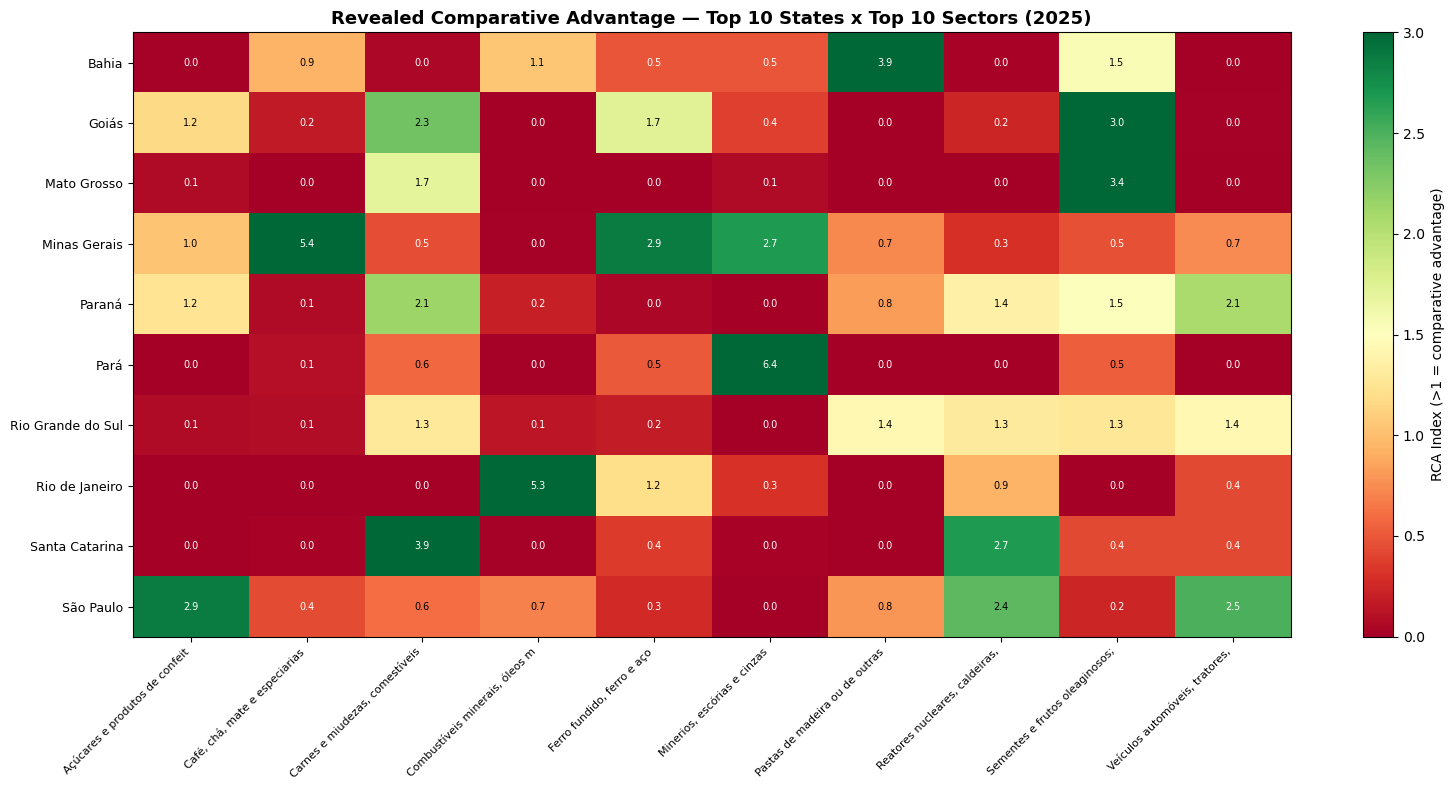


Top 5 sectors by RCA per state (2025) — sectors where RCA > 1 indicate comparative advantage

  São Paulo
    Aeronaves e aparelhos espaciais, e suas parte RCA=4.65  $4.54bn
    Estanho e suas obras                          RCA=4.41  $0.26bn
    Fibras sintéticas ou artificiais, descontínua RCA=4.18  $0.05bn
    Produtos para fotografia e cinematografia     RCA=4.07  $0.03bn
    Tapetes e outros revestimentos para pisos (pa RCA=4.01  $0.02bn

  Rio de Janeiro
    Combustíveis minerais, óleos minerais e produ RCA=5.30  $40.79bn
    Níquel e suas obras                           RCA=2.57  $0.02bn
    Embarcações e estruturas flutuantes           RCA=1.97  $0.02bn
    Obras de espartaria ou de cestaria            RCA=1.57  $0.00bn
    Borracha e suas obras                         RCA=1.26  $0.34bn

  Minas Gerais
    Zinco e suas obras                            RCA=7.32  $0.19bn
    Outros metais comuns; ceramais (cermets); obr RCA=6.96  $0.20bn
    Café, chá, mate e especiarias         

In [8]:
## Exports by state and SH2 sector
query_rca = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2 AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""
df_rca_raw = pd.read_sql(query_rca, engine)
## Remove non-geographic entries carried over from df_rca_raw
df_rca_raw = df_rca_raw[~df_rca_raw['state'].isin(['Não Declarada', 'Exterior'])]
## State total exports
state_totals = df_rca_raw.groupby('uf')['exports_usd'].sum().rename('state_total')
df_rca_raw   = df_rca_raw.join(state_totals, on='uf')
## National total exports per sector
national_sector = df_rca_raw.groupby('sector')['exports_usd'].sum().rename('national_sector')
df_rca_raw      = df_rca_raw.join(national_sector, on='sector')
## National total exports
national_total = df_rca_raw['exports_usd'].sum()
## RCA = (state_sector / state_total) / (national_sector / national_total)
df_rca_raw['state_sector_share']    = df_rca_raw['exports_usd']    / df_rca_raw['state_total']
df_rca_raw['national_sector_share'] = df_rca_raw['national_sector'] / national_total
df_rca_raw['rca'] = (df_rca_raw['state_sector_share'] / df_rca_raw['national_sector_share']).round(3)
## Focus on top 10 exporting states and top 10 sectors by national value
top10_states  = df_state.head(10)['state'].tolist()
top10_sectors = (
    df_rca_raw.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)
df_rca_heat = df_rca_raw[
    df_rca_raw['state'].isin(top10_states) &
    df_rca_raw['sector'].isin(top10_sectors)
].pivot(index='state', columns='sector', values='rca').fillna(0)
## Shorten sector labels for readability
df_rca_heat.columns = [str(c)[:30] for c in df_rca_heat.columns]
## Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(df_rca_heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(df_rca_heat.columns)))
ax.set_xticklabels(df_rca_heat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_rca_heat.index)))
ax.set_yticklabels(df_rca_heat.index, fontsize=9)
## Annotate cells with RCA value
for i in range(len(df_rca_heat.index)):
    for j in range(len(df_rca_heat.columns)):
        val = df_rca_heat.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                color='black' if 0.5 < val < 2.5 else 'white')
plt.colorbar(im, ax=ax, label='RCA Index (>1 = comparative advantage)')
ax.set_title(f'Revealed Comparative Advantage — Top 10 States x Top 10 Sectors ({MAX_YEAR})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b1_rca_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
## Print top 5 RCA sectors per state
print(f"\nTop 5 sectors by RCA per state ({MAX_YEAR}) — sectors where RCA > 1 indicate comparative advantage")
for state in top10_states:
    subset = df_rca_raw[
        (df_rca_raw['state'] == state) & (df_rca_raw['rca'] > 1)
    ].nlargest(5, 'rca')[['sector', 'rca', 'exports_usd']]
    subset['exports_usd_bn'] = (subset['exports_usd'] / 1e9).round(2)
    print(f"\n  {state}")
    if subset.empty:
        print("    No sectors with RCA > 1")
    else:
        for _, row in subset.iterrows():
            print(f"    {str(row['sector'])[:45]:<45} RCA={row['rca']:.2f}  ${row['exports_usd_bn']:.2f}bn")

### Overall Pattern

The RCA results reveal a clear structural divide in Brazil's state-level export competitiveness. States in the Center-West and North show strong comparative advantages concentrated in agricultural commodities and mineral extraction respectively, while the Southeast leads in industrial and manufactured goods — particularly São Paulo in aerospace, vehicles and machinery, and Minas Gerais in coffee and iron ore. The South and Northeast are the most structurally diverse regions, with RCA values above 1 spanning both commodity and industrial sectors. The South's competitive strengths sit primarily in diversified agro-industrial goods — processed meats, grains and forestry products — while the Northeast spans the full spectrum from commodity monocultures in states like Piauí to emerging industrial competitiveness in semi-finished steel and vehicles.

However RCA measures relative specialisation rather than absolute scale — a state can show strong comparative advantage in a sector that represents a negligible share of national or global output. Many high-RCA sectors across states such as Paraná, Santa Catarina and Bahia are built on export values below \$0.10bn, reflecting niche or residual specialisations rather than structural industrial capacity. The cases where high RCA and material export value coincide — Rio de Janeiro in mineral fuels (\\$40.79bn, RCA 5.30), Pará in ores (\\$15.73bn, RCA 6.42), Minas Gerais in coffee (\\$11.29bn, RCA 5.45) and iron ore (\\$4.67bn, RCA 2.87), São Paulo in aerospace (\\$4.54bn, RCA 4.65), Mato Grosso in soybeans (\\$13.17bn, RCA 3.39), cotton (\\$3.13bn, RCA 7.11) and cereals (\\$4.67bn, RCA 5.67), and Rio Grande do Sul in tobacco (\\$3.05bn, RCA 14.45) — represent the clearest cases of genuine structural competitive advantage. Notably all of these are commodity or agro-processed sectors, reinforcing the finding from cell 2.13 that Brazil's export composition shifted from 56% manufactured goods in 1997 to 58.2% primary commodities by 2025.

---

### Interesting Observations

- Rio de Janeiro is the only state where a single sector dominates both RCA and absolute value simultaneously (\$40.79bn, RCA 5.30) — unique in the dataset
- Bahia's cocoa (RCA 20.44, \\$0.55bn) is the most economically meaningful high-RCA agro-processed sector outside the major commodity states
- The textile RCA cluster in Santa Catarina (four sectors above RCA 13, all below \\$0.06bn) is the clearest example of the small-denominator artefact problem in this dataset

> ⚠️ *Requires further investigation (Step 5): Do the high-RCA low-value sectors in Paraná, Santa Catarina and Rio Grande do Sul represent genuine emerging competitiveness or statistical artefacts of small national market shares?*


## 2b.2 — Krugman Specialisation Index by State

The Krugman Specialisation Index measures how structurally different a state's export basket is from Brazil's national export mix. It is computed as the sum of absolute differences between each state's sector share and the corresponding national sector share across all SH2 sectors.

**Formula:** KSI = Σ |state_sector_share - national_sector_share| for all sectors

**Range:** 0 to 2, where:
- **0** — the state's export mix is identical to the national mix
- **> 1** — the state is highly specialised relative to Brazil as a whole
- **2** — the state's export mix shares no sectors with the national mix

A high KSI indicates a state exports a structurally distinct set of products relative to the national average. A low KSI indicates the state's export composition broadly mirrors Brazil's overall sectoral distribution.

Note: the KSI captures structural divergence from the national mix but does not indicate whether that divergence is driven by commodity concentration or industrial diversification — a state can score high by specialising in either soybeans or aerospace. The HHI in cell 2b.3 complements this by measuring within-state product concentration independently of the national benchmark.

C:\Users\e_koh\AppData\Local\Temp\ipykernel_28184\2269547088.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())


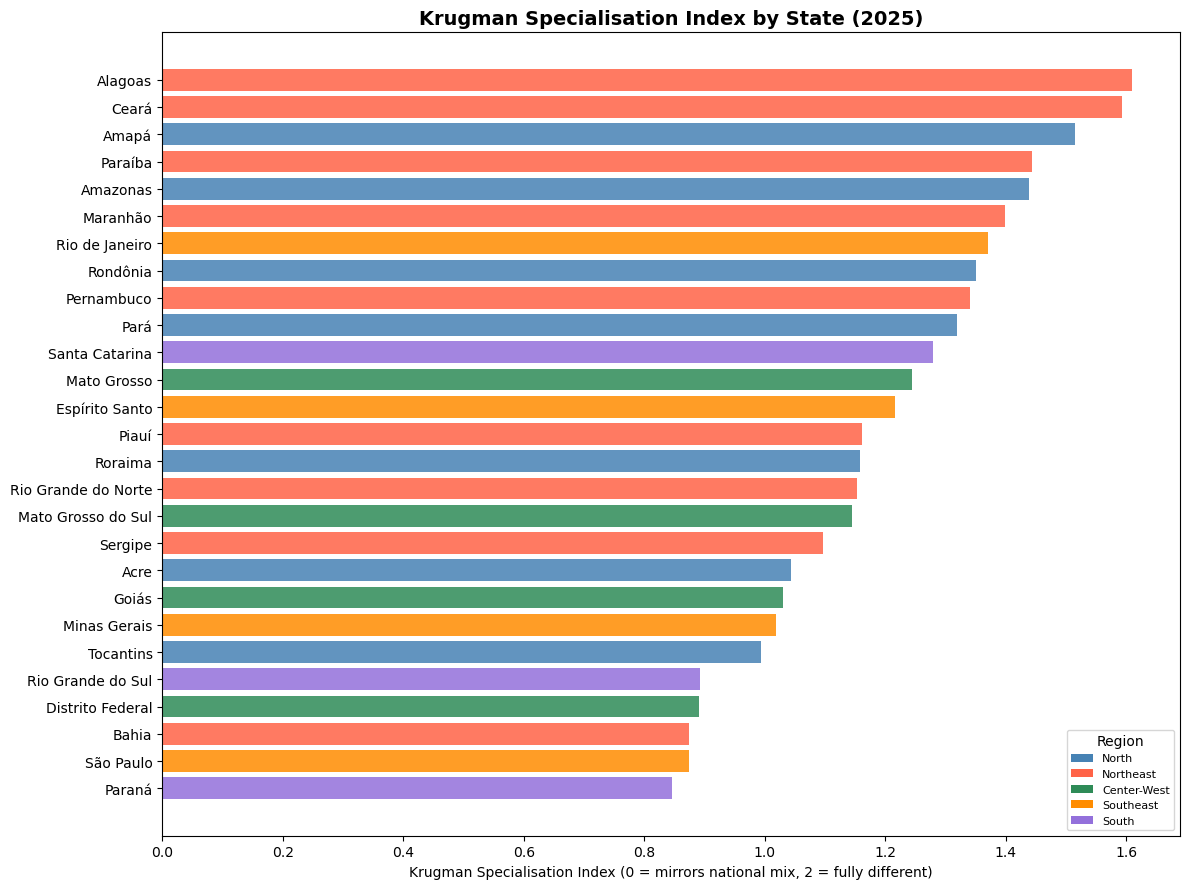


Krugman Specialisation Index by state (2025)
Higher KSI = more specialised / less diversified relative to national mix
              state      region  exports_usd_bn  krugman_idx
            Alagoas   Northeast            0.82       1.6084
              Ceará   Northeast            2.28       1.5934
              Amapá       North            0.14       1.5147
            Paraíba   Northeast            0.18       1.4431
           Amazonas       North            0.94       1.4380
           Maranhão   Northeast            5.02       1.3988
     Rio de Janeiro   Southeast           48.98       1.3696
           Rondônia       North            3.09       1.3509
         Pernambuco   Northeast            2.54       1.3401
               Pará       North           24.34       1.3181
     Santa Catarina       South           12.20       1.2783
        Mato Grosso Center-West           30.19       1.2439
     Espírito Santo   Southeast           10.51       1.2157
              Piauí   Nort

In [12]:
df_krugman = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())
    .reset_index()
    .rename(columns={0: 'krugman_idx'})
)
df_krugman['krugman_idx'] = df_krugman['krugman_idx'].round(4)
df_krugman = df_krugman.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')

## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_krugman['region'] = df_krugman['region'].map(region_name_map).fillna(df_krugman['region'])

df_krugman_plot = df_krugman.sort_values('krugman_idx', ascending=True)
## Colour by region
region_colors = {
    r: c for r, c in zip(
        df_krugman['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}
bar_colors = df_krugman_plot['region'].map(region_colors).fillna('lightgray')
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_krugman_plot['state'], df_krugman_plot['krugman_idx'], color=bar_colors, alpha=0.85)
ax.set_title(f'Krugman Specialisation Index by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Krugman Specialisation Index (0 = mirrors national mix, 2 = fully different)')
## Region legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b2_krugman.png', dpi=150)
plt.show()
print(f"\nKrugman Specialisation Index by state ({MAX_YEAR})")
print("Higher KSI = more specialised / less diversified relative to national mix")
print(df_krugman[['state', 'region', 'exports_usd_bn', 'krugman_idx']]
      .sort_values('krugman_idx', ascending=False)
      .to_string(index=False))

### Overview

The Krugman Specialisation Index (KSI) measures how far each state's export mix deviates from Brazil's national average. A high KSI means the state exports a structurally different basket of goods from Brazil's overall mix — typically indicating heavy concentration in one or two sectors. A low KSI means the state mirrors the national mix closely — typically indicating a diversified export base that reflects the full breadth of Brazil's sectoral composition.

**Range in this dataset: 0.85 (Paraná) to 1.61 (Alagoas)**

---

## Regional Pattern

| Region | Average KSI | Interpretation |
|---|---|---|
| Northeast | ~1.35 | Highest average specialisation — commodity and monoculture driven 
| North | ~1.30 | High specialisation — natural resource extraction |
| Southeast) | ~1.13 | Wide range — São Paulo pulls down, Rio de Janeiro pulls up |
| Center-West | ~1.10 | Moderate — agricultural with some diversification |
| South | ~1.01 | Closest to national average — most diversified region |

The Southern region's average KSI closest to 1.0 confirms what the RCA and HHI analyses suggested — the three Southern states (Paraná, Santa Catarina, Rio Grande do Sul) collectively produce the most nationally representative export basket.

---

## Observations

**Large exporters can still be highly specialised** — Rio de Janeiro (\\$48.98bn, KSI 1.36) and Mato Grosso (\\$30.19bn, KSI 1.25) demonstrate that high export value does not imply diversification. Both are structurally concentrated in single commodity clusters.

**Small exporters tend toward higher specialisation** — Alagoas (\\$0.82bn), Amapá (\\$0.14bn) and Paraíba (\\$0.18bn) all score above 1.40. Small states with one dominant product naturally deviate further from the national mix.

**São Paulo as the national benchmark** — with a KSI of 0.88 and the largest absolute export value (\\$71.39bn), São Paulo's export mix is effectively embedded in the national average. Any state that deviates significantly from São Paulo's profile will tend to show a high KSI.

> ⚠️ *A low KSI does not indicate industrial sophistication — it indicates similarity to the national average. Given that 58.2% of Brazil's national exports are now primary commodities (cell 2.13), a state can score low KSI by exporting a commodity-diversified basket rather than an industrial one.*

> ⚠️ *Requires further investigation (Step 5): What specific SH2 sectors drive Ceará's high KSI (1.59) given it does not have an obvious single-commodity anchor like Alagoas (sugar) or Rio de Janeiro (oil)? The CSP semi-finished steel plant is the most likely driver — confirmed by the NCM analysis in cell 2.7 — but this warrants product-level verification.*

## 2b.3 — Product Concentration Index by State (HHI at Product Level)
The HHI (Herfindahl-Hirschman Index) at the SH2 sector level measures how concentrated each state's export basket is. A high HHI means the state depends heavily on one or two sectors. A low HHI means exports are spread across many sectors.

**Formula:** HHI = sum of (sector_share)² for all sectors in a state

**Range**: close to 0 (very diversified) to 1 (single product monopoly).

C:\Users\e_koh\AppData\Local\Temp\ipykernel_28184\1598565369.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] ** 2).sum())


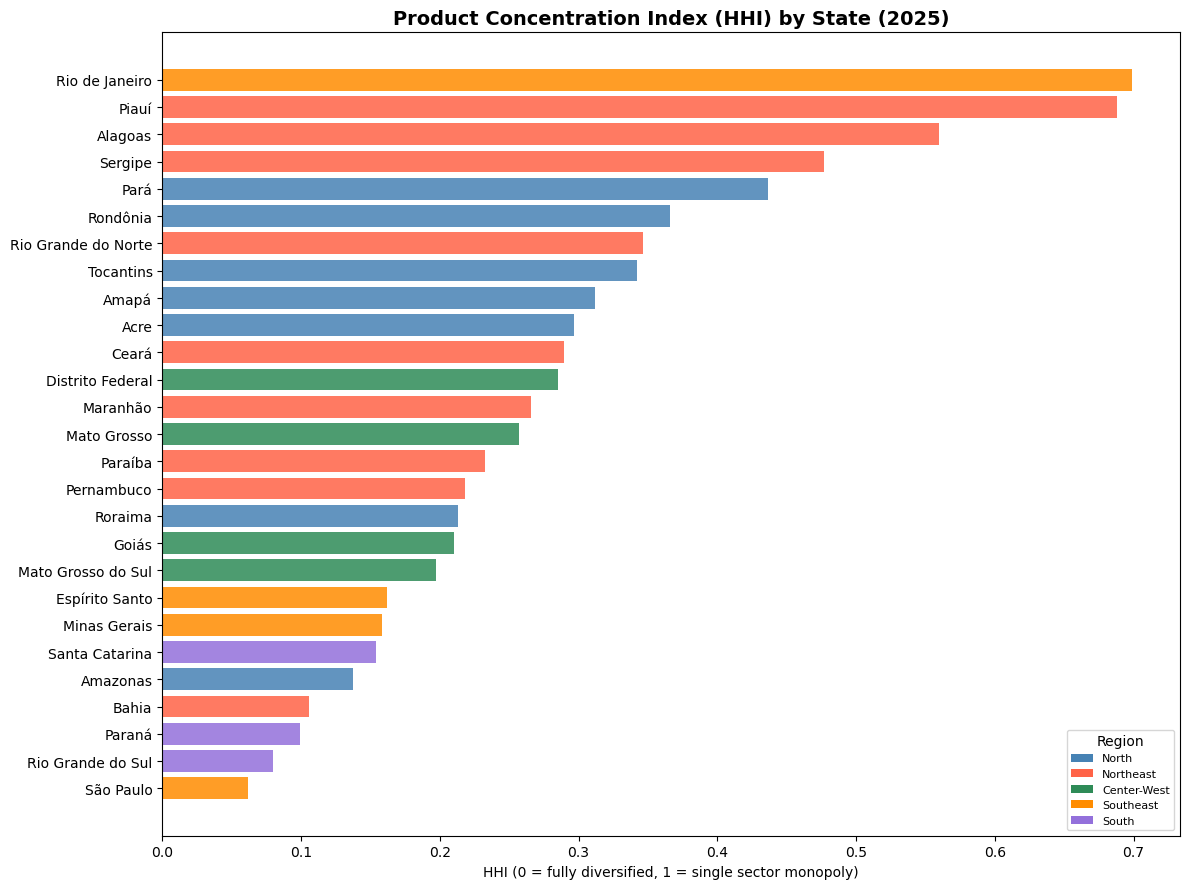


Product concentration HHI by state (2025)
Higher HHI = more concentrated in fewer sectors
              state      region  exports_usd_bn    hhi
     Rio de Janeiro   Southeast           48.98 0.6985
              Piauí   Northeast            1.20 0.6879
            Alagoas   Northeast            0.82 0.5594
            Sergipe   Northeast            0.45 0.4771
               Pará       North           24.34 0.4365
           Rondônia       North            3.09 0.3658
Rio Grande do Norte   Northeast            1.13 0.3462
          Tocantins       North            3.05 0.3418
              Amapá       North            0.14 0.3119
               Acre       North            0.10 0.2969
              Ceará   Northeast            2.28 0.2894
   Distrito Federal Center-West            0.32 0.2852
           Maranhão   Northeast            5.02 0.2660
        Mato Grosso Center-West           30.19 0.2571
            Paraíba   Northeast            0.18 0.2323
         Pernambuco   Northea

In [13]:
df_hhi_prod = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] ** 2).sum())
    .reset_index()
    .rename(columns={0: 'hhi'})
)
df_hhi_prod['hhi'] = df_hhi_prod['hhi'].round(4)
df_hhi_prod = df_hhi_prod.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')

## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_hhi_prod['region'] = df_hhi_prod['region'].map(region_name_map).fillna(df_hhi_prod['region'])

df_hhi_plot = df_hhi_prod.sort_values('hhi', ascending=True)

## Colour by region — rebuild colors from df_hhi_plot to match translated names
region_colors_hhi = {
    r: c for r, c in zip(
        df_hhi_prod['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}
bar_colors = df_hhi_plot['region'].map(region_colors_hhi).fillna('lightgray')

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_hhi_plot['state'], df_hhi_plot['hhi'], color=bar_colors, alpha=0.85)
ax.set_title(f'Product Concentration Index (HHI) by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('HHI (0 = fully diversified, 1 = single sector monopoly)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors_hhi.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b3_hhi_product.png', dpi=150)
plt.show()
print(f"\nProduct concentration HHI by state ({MAX_YEAR})")
print("Higher HHI = more concentrated in fewer sectors")
print(df_hhi_prod[['state', 'region', 'exports_usd_bn', 'hhi']]
      .sort_values('hhi', ascending=False)
      .to_string(index=False))

### Overview

**Range in this dataset: 0.062 (São Paulo) to 0.699 (Rio de Janeiro)**

---

### Featured States

**Rio de Janeiro (HHI 0.699)** — the most concentrated large exporter in Brazil by a significant margin. Oil and gas exports (\\$40.79bn) account for the overwhelming majority of the state's \\$48.98bn total — confirmed by the NCM analysis in cell 2.7. The combination of extreme concentration and large absolute export value is unique in the dataset — no other state of comparable size is this structurally dependent on a single sector.

**Ceará (HHI 0.289)** — resolves the open flag from the KSI analysis. Ceará has high KSI (1.59) but moderate HHI, which initially appears contradictory. The explanation is that Ceará's deviation from the national mix is driven by a cluster of related semi-manufactured steel products (NCM analysis in cell 2.7) — rather than a single dominant SH2 chapter. High specialisation relative to the national mix does not require internal concentration.

**Alagoas (HHI 0.559)** — the clearest multi-metric convergence in Step 2b. KSI 1.61 (highest in Brazil), HHI 0.559 and RCA above 16 all point to the same conclusion: Alagoas is Brazil's most monoculture-dependent exporting state across every metric simultaneously.

**Amazonas (HHI 0.137)** — lower concentration than expected given the Zona Franca de Manaus profile. Its low HHI reflects manufactured goods diversification across electronics, motorcycles and food processing — structurally different from the commodity diversification seen in Mato Grosso, which achieves a similar HHI (0.257) through multiple crop categories rather than industrial variety.

---

### Observations

**The KSI-HHI relationship is not straightforward.** A state can have high KSI (specialised relative to national) and moderate HHI (internally diversified), as Ceará demonstrates. Conversely a state can have moderate KSI and very high HHI, as Rio de Janeiro shows. These two metrics capture different dimensions of specialisation and should always be read together.

**Large export value does not guarantee diversification** — Rio de Janeiro (\\$48.98bn, HHI 0.699) and Pará (\\$24.34bn, HHI 0.437) are both large exporters with high concentration. Export scale and export diversification are structurally independent.

**The Sul states form a distinctly low-HHI cluster** — Paraná (0.099), Rio Grande do Sul (0.080) and Santa Catarina (0.154) all sit in the bottom third of the HHI ranking. This is the most consistently diversified region across all three metrics — RCA, KSI and HHI.

**Norte and Nordeste dominate the high-HHI end** — 9 of the top 10 most concentrated states are from these two regions. The exception being Rio de Janeiro (Southeast, oil-driven).

| HHI Band | States | Regional Pattern |
|---|---|---|
| > 0.40 | Rio de Janeiro, Piauí, Alagoas, Sergipe, Pará | Southeast outlier + North/Northeast commodity states |
| 0.20–0.40 | Rondônia, Rio Grande do Norte, Tocantins, Amapá, Acre, Ceará, DF, Maranhão, Mato Grosso, Paraíba, Pernambuco, Roraima, Goiás, Mato Grosso do Sul | Broad mix |
| < 0.20 | Espírito Santo, Minas Gerais, Santa Catarina, Amazonas, Bahia, Paraná, Rio Grande do Sul, São Paulo | Predominantly South and Southeast |


> ⚠️ *Rio de Janeiro's HHI (0.699) combined with \$48.98bn in exports represents the single largest concentration risk in Brazil's state-level export profile. A sustained decline in oil prices or an accelerated energy transition would disproportionately impact one of Brazil's largest exporting states.*

## 2b.4 — Export Frequency: Number of Shipments by State
Counting the number of export transactions (rows) per state per year as a proxy for shipment frequency.

In [14]:
query_freq = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           SUM(e."QT_ESTAT") AS total_units
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY shipment_count DESC
"""

df_freq = pd.read_sql(query_freq, engine)
df_freq = df_freq[~df_freq['state'].isin(['Não Declarada', 'Exterior'])]
df_freq['exports_usd_bn']    = (df_freq['exports_usd'] / 1e9).round(2)
df_freq['shipment_count_(000`s)']  = (df_freq['shipment_count'] / 1000).round(1)



print(f"\nExport shipment frequency by state ({MAX_YEAR})")
print(df_freq[['state', 'exports_usd_bn', 'shipment_count', 'shipment_count_(000`s)']]
      .sort_values('shipment_count', ascending=False)
      .to_string(index=False))


Export shipment frequency by state (2025)
              state  exports_usd_bn  shipment_count  shipment_count_(000`s)
          São Paulo           71.39          633996                   634.0
  Rio Grande do Sul           21.53          200290                   200.3
     Santa Catarina           12.20          198582                   198.6
             Paraná           23.65          168230                   168.2
     Rio de Janeiro           48.98          125063                   125.1
       Minas Gerais           45.83           84438                    84.4
     Espírito Santo           10.51           64958                    65.0
               Pará           24.34           30292                    30.3
           Maranhão            5.02           30183                    30.2
              Bahia           11.63           27716                    27.7
              Ceará            2.28           25439                    25.4
            Alagoas            0.82          

### Overview

Shipment frequency (number of export transactions) is used as a proxy for the operational profile of each state's export base. 

States with high shipment frequency tend toward lower product concentration (HHI) — a relationship quantified in the regression analysis in cell 2b.5 (pooled R² = 0.336, slope = -0.1226, significant in 25 of 29 years). Whether high frequency also corresponds to broader destination markets and smaller individual transaction sizes is examined in cells 2.17 (market concentration) while the relationship between frequency and individual transaction size is explored directly in cell 2b.5.

**Range in this dataset: 695 transactions (Sergipe) to 633,996 (São Paulo)**

The spread across this metric is the largest of any indicator in Step 2b — São Paulo transacts nearly 1,000 times more than Sergipe. This reflects a fundamental structural difference in how different Brazilian states participate in global trade.


***Note**: Shipment count is derived from row count in the `exp` table rather than an official transaction register — liquid bulk commodities such as oil may generate records at a different granularity than containerised or solid bulk goods, which could explain Rio de Janeiro's anomalously high frequency.*

---

### Key Findings

**São Paulo (634k transactions)** leads by a wide margin — nearly twice the frequency of Rio Grande do Sul (200k) in second place. This is consistent with São Paulo's role as Brazil's industrial and logistics hub, where diverse export products ship regularly across many sectors and destinations.

**Rio Grande do Sul (200k) and Santa Catarina (199k)** are virtually tied for second and third — both Sul states with diversified agro-industrial export bases generating high transaction volumes across meat, machinery, chemicals and agricultural products. Their frequency is disproportionately high relative to their export value, suggesting many smaller-value shipments rather than a few large ones.

**Rio de Janeiro (125k)** is the most analytically significant finding in this cell. With HHI 0.699 — the most concentrated export state in Brazil — one would expect low frequency. Instead it ranks fifth with 125k transactions, driven by the operational nature of oil and gas exports which generate many individual transaction records through the port processing system despite being a single commodity. This is the primary driver of the regression outlier identified in cell 2b.5.

**Mato Grosso (9.4k) and Mato Grosso do Sul (9.9k)** are the most striking low-frequency large exporters. Mato Grosso exports \\$30.19bn through only 9,400 transactions — fewer than Roraima (\\$0.24bn, 6.4k) on a per-value basis. This reflects the bulk agricultural nature of soybean and corn exports: very large individual shipments, very few transactions.

**Piauí (0.7k) and Sergipe (0.7k)** are the lowest frequency states — both small exporters with highly concentrated product profiles, consistent with their high HHI values.

---

### Observations

**Frequency scales with industrial diversification, not export value.** The top 5 states by frequency — São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Rio de Janeiro - are not the top 5 by export value — Mato Grosso (\\$30.19bn, ranked 3rd by value) ranks 17th by frequency. Frequency reflects how many distinct products and shipments a state generates, not how much revenue those shipments produce.

**The Southern cluster dominates mid-to-high frequency** — Paraná (168k), Rio Grande do Sul (200k) and Santa Catarina (199k) collectively generate 567k transactions on \\$57.4bn of exports. The Center-West generates \$54.7bn through only 35k transactions. Same export value, 16x fewer shipments — the clearest quantitative expression of the bulk commodity vs diversified industrial divide in Step 2b.

**The relationship between frequency and HHI is confirmed directionally** — states with low frequency (Mato Grosso, Piauí, Sergipe, Tocantins) all have high HHI, and states with high frequency (São Paulo, Rio Grande do Sul, Santa Catarina, Paraná) all have low HHI. Rio de Janeiro is the single exception, driven by oil port processing volumes rather than genuine product diversification. The regression in cell 2b.5 quantifies this relationship (pooled R² = 0.336, slope = -0.1226, significant in 25 of 29 years).

**The value-frequency ratio reveals the commodity-industrial divide.** Mato Grosso (\\$30.19bn, 9k transactions = \\$3.2m per transaction) vs São Paulo (\\$71.39bn, 634k transactions = \\$113k per transaction) illustrates the structural difference between bulk commodity and industrial export profiles more vividly than RCA or HHI alone.

**The Nordeste frequency range is the widest of any region** — from Bahia (28k) and Ceará (25k) at the top to Sergipe (695) and Piauí (704) at the bottom. This reflects the internal economic heterogeneity of the Nordeste — industrialising coastal states alongside underdeveloped agricultural interior states.

---

### Frequency Summary Table

| Tier | States | Shipment Count | Exports |
|---|---|---|---|
| High (> 100k) | São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Rio de Janeiro | 634k – 125k | \$12–71bn |
| Mid-High (25k–100k) | Minas Gerais, Espírito Santo, Pará, Maranhão, Bahia, Ceará | 84k – 25k | \$2–46bn |
| Mid-Low (5k–25k) | Alagoas, Pernambuco, Amazonas, Goiás, Mato Grosso do Sul, Mato Grosso, Roraima, Amapá | 19k – 5k | \$0.1–30bn |
| Low (< 5k) | Rondônia, Rio Grande do Norte, Distrito Federal, Tocantins, Paraíba, Acre, Piauí, Sergipe | 3.8k – 0.7k | \$0.1–3bn |


## 2b.5 — Average Shipment Size by State (kg and USD per Transaction)
Average shipment size is calculated as total kg and total USD divided by the number of transactions. Large average shipments indicate bulk commodity exports. Small average shipments indicate high-frequency industrial or processed goods exports.

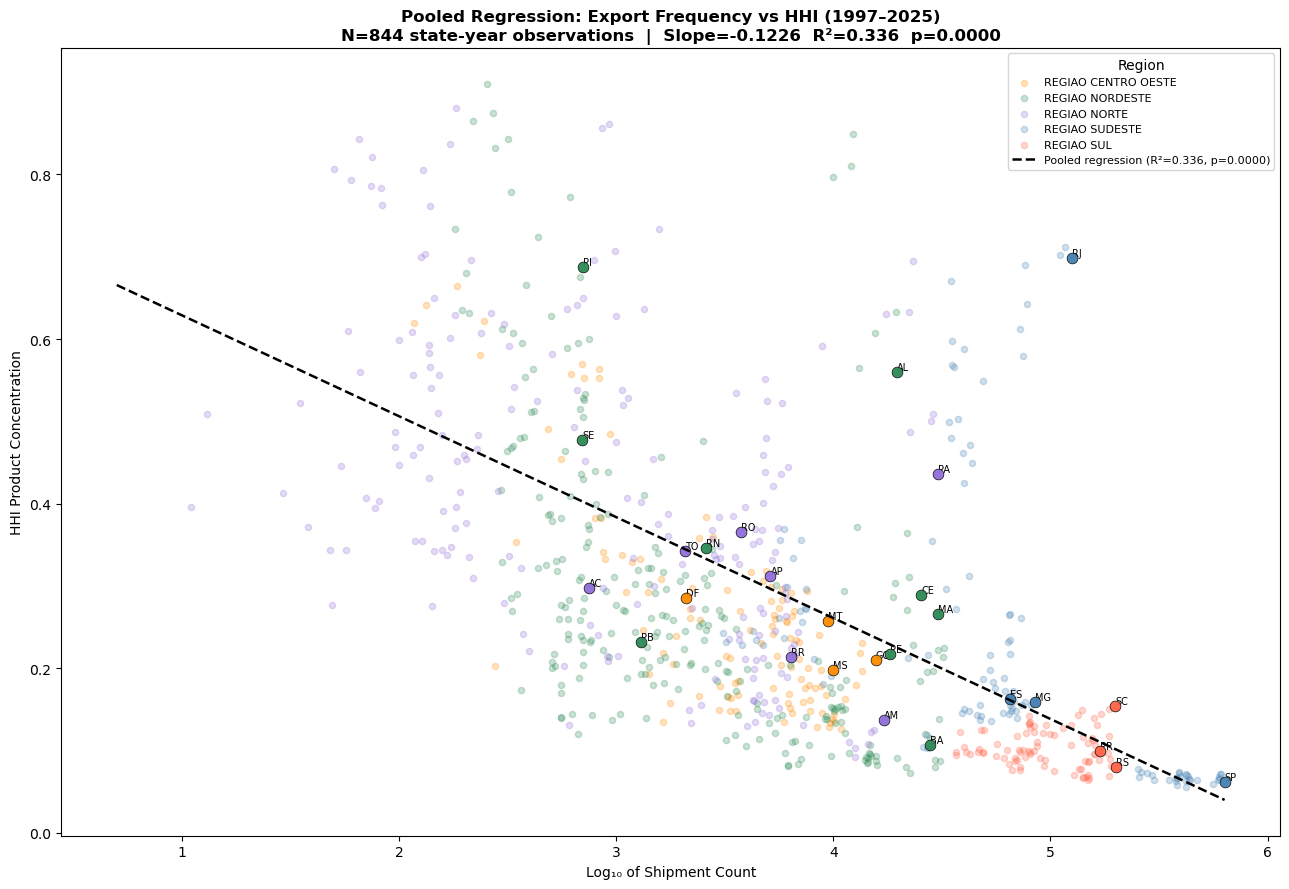


Pooled Regression Results (1997–2025)
  N observations: 844
  Slope:          -0.1226
  Intercept:      0.7513
  R²:             0.3361
  p-value:        0.000000
  Std Error:      0.0059


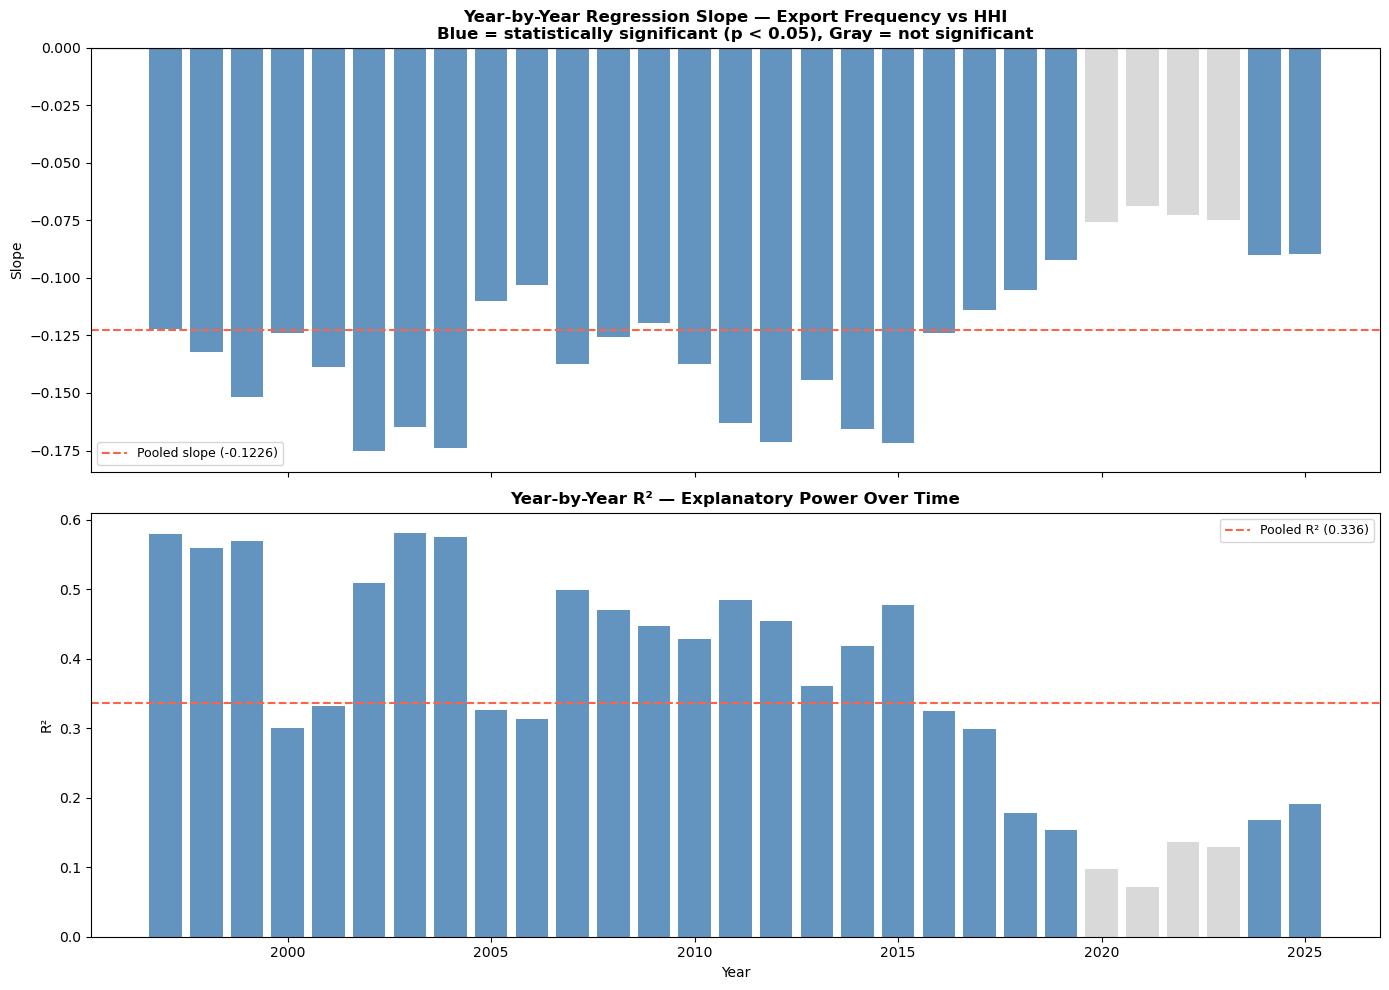


Year-by-Year Regression Results:
 year   slope  r_squared  p_value  n
 1997 -0.1222     0.5792   0.0000 29
 1998 -0.1320     0.5590   0.0000 29
 1999 -0.1518     0.5702   0.0000 29
 2000 -0.1239     0.3005   0.0021 29
 2001 -0.1388     0.3326   0.0011 29
 2002 -0.1754     0.5095   0.0000 29
 2003 -0.1647     0.5810   0.0000 29
 2004 -0.1739     0.5752   0.0000 29
 2005 -0.1101     0.3265   0.0010 30
 2006 -0.1033     0.3129   0.0013 30
 2007 -0.1376     0.4990   0.0000 30
 2008 -0.1257     0.4700   0.0000 30
 2009 -0.1196     0.4478   0.0001 30
 2010 -0.1372     0.4282   0.0001 30
 2011 -0.1632     0.4842   0.0000 31
 2012 -0.1713     0.4546   0.0000 31
 2013 -0.1443     0.3604   0.0004 31
 2014 -0.1657     0.4187   0.0001 31
 2015 -0.1718     0.4777   0.0000 30
 2016 -0.1239     0.3253   0.0008 31
 2017 -0.1139     0.2990   0.0018 30
 2018 -0.1052     0.1780   0.0253 28
 2019 -0.0924     0.1540   0.0429 27
 2020 -0.0758     0.0978   0.1122 27
 2021 -0.0686     0.0709   0.1795 27
 202

In [38]:
## Regression: Export Shipment Frequency vs HHI — All Years (1997–MAX_YEAR)
## Pooled panel regression + year-by-year regression to test structural stability

from scipy import stats

## ---- Query: frequency and HHI for all years ----
query_freq_all = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, shipment_count DESC
"""

query_hhi_all = f"""
    SELECT year, uf,
           SUM(sector_exports * sector_exports) /
           (SUM(sector_exports) * SUM(sector_exports)) AS hhi
    FROM (
        SELECT e."CO_ANO" AS year,
               e."SG_UF_NCM" AS uf,
               s.codigo_sh2,
               SUM(e."VL_FOB") AS sector_exports
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
        WHERE e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."CO_ANO", e."SG_UF_NCM", s.codigo_sh2
    ) t
    GROUP BY year, uf
    ORDER BY year, uf
"""

df_freq_all = pd.read_sql(query_freq_all, engine)
df_hhi_all  = pd.read_sql(query_hhi_all,  engine)

df_freq_all['exports_usd_bn'] = df_freq_all['exports_usd'] / 1e9

## Merge and clean
df_panel = df_freq_all.merge(df_hhi_all, on=['year', 'uf'], how='inner')
df_panel = df_panel.merge(df_state[['uf', 'region']], on='uf', how='left')
df_panel = df_panel[~df_panel['region'].isin(['REGIAO NAO DECLARADA'])]
df_panel = df_panel[~df_panel['state'].isin(['Não Declarada', 'Exterior'])]
df_panel['log_shipment_count'] = np.log10(df_panel['shipment_count'])

## ---- Part 1: Pooled regression (all years combined) ----
slope_p, intercept_p, r_value_p, p_value_p, std_err_p = stats.linregress(
    df_panel['log_shipment_count'], df_panel['hhi']
)
r_squared_p = r_value_p ** 2

x_line = np.linspace(df_panel['log_shipment_count'].min(),
                     df_panel['log_shipment_count'].max(), 100)
y_line = slope_p * x_line + intercept_p

region_colors_reg = {
    r: c for r, c in zip(
        df_panel['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

fig, ax = plt.subplots(figsize=(13, 9))
for region, group in df_panel.groupby('region'):
    color = region_colors_reg.get(region, 'gray')
    ax.scatter(
        group['log_shipment_count'],
        group['hhi'],
        label=region,
        color=color,
        s=20,
        alpha=0.25,
        zorder=2
    )

## Overlay MAX_YEAR points with labels for reference
df_latest = df_panel[df_panel['year'] == MAX_YEAR]
for region, group in df_latest.groupby('region'):
    color = region_colors_reg.get(region, 'gray')
    ax.scatter(group['log_shipment_count'], group['hhi'],
               color=color, s=60, alpha=0.95, zorder=4, edgecolors='black', linewidths=0.5)
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['log_shipment_count'], row['hhi']),
                    fontsize=7, ha='left', va='bottom')

ax.plot(x_line, y_line, color='black', linewidth=1.8, linestyle='--',
        label=f'Pooled regression (R²={r_squared_p:.3f}, p={p_value_p:.4f})',
        zorder=5)

ax.set_title(f'Pooled Regression: Export Frequency vs HHI (1997–{MAX_YEAR})\n'
             f'N={len(df_panel)} state-year observations  |  '
             f'Slope={slope_p:.4f}  R²={r_squared_p:.3f}  p={p_value_p:.4f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Log₁₀ of Shipment Count')
ax.set_ylabel('HHI Product Concentration')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b4b_regression_pooled.png', dpi=150)
plt.show()

print(f"\nPooled Regression Results (1997–{MAX_YEAR})")
print(f"  N observations: {len(df_panel)}")
print(f"  Slope:          {slope_p:.4f}")
print(f"  Intercept:      {intercept_p:.4f}")
print(f"  R²:             {r_squared_p:.4f}")
print(f"  p-value:        {p_value_p:.6f}")
print(f"  Std Error:      {std_err_p:.4f}")

## ---- Part 2: Year-by-year regression ----
yearly_results = []
for year, group in df_panel.groupby('year'):
    if len(group) < 5:
        continue
    s, i, r, p, se = stats.linregress(group['log_shipment_count'], group['hhi'])
    yearly_results.append({
        'year'     : year,
        'slope'    : round(s, 4),
        'r_squared': round(r ** 2, 4),
        'p_value'  : round(p, 4),
        'n'        : len(group)
    })

df_yearly = pd.DataFrame(yearly_results)

## Plot year-by-year slope and R²
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

## Colour significant years
colors_sig = ['steelblue' if p < 0.05 else 'lightgray' for p in df_yearly['p_value']]

ax1.bar(df_yearly['year'], df_yearly['slope'], color=colors_sig, alpha=0.85)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axhline(y=slope_p, color='tomato', linewidth=1.5, linestyle='--',
            label=f'Pooled slope ({slope_p:.4f})')
ax1.set_title('Year-by-Year Regression Slope — Export Frequency vs HHI\n'
              'Blue = statistically significant (p < 0.05), Gray = not significant',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope')
ax1.legend(fontsize=9)

ax2.bar(df_yearly['year'], df_yearly['r_squared'], color=colors_sig, alpha=0.85)
ax2.axhline(y=r_squared_p, color='tomato', linewidth=1.5, linestyle='--',
            label=f'Pooled R² ({r_squared_p:.3f})')
ax2.set_title('Year-by-Year R² — Explanatory Power Over Time',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_xlabel('Year')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output_2b4c_regression_yearly.png', dpi=150)
plt.show()

print(f"\nYear-by-Year Regression Results:")
print(df_yearly.to_string(index=False))

## Summary: how many years are statistically significant
sig_years = df_yearly[df_yearly['p_value'] < 0.05]
print(f"\n  Significant years (p < 0.05): {len(sig_years)} of {len(df_yearly)}")
print(f"  Average slope (all years):        {df_yearly['slope'].mean():.4f}")
print(f"  Average slope (significant only): {sig_years['slope'].mean():.4f}")
print(f"  Average R² (all years):           {df_yearly['r_squared'].mean():.4f}")
print(f"  Average R² (significant only):    {sig_years['r_squared'].mean():.4f}")

### Overview

Testing whether states that export more frequently also tend to have more diversified product baskets. A statistically significant negative relationship (slope = -0.09, R² = 0.19, p = 0.022) confirms that high-frequency states such as São Paulo, Rio Grande do Sul and Santa Catarina are also the most diversified exporters. Rio de Janeiro is the key outlier — high frequency but the most concentrated export basket in Brazil, likely driven by oil and gas. States are plotted on a log scale given the large range in shipment counts across Brazil's 27 states. 
Bubble size reflects total export value. 

REGIAO NAO DECLARADA was excluded from regression.

### Pooled Regression Summary

| Metric | Value |
|---|---|
| N observations | 844 (27 states × ~29 years) |
| Slope | -0.1226 |
| Intercept | 0.7513 |
| R² | 0.3361 |
| p-value | < 0.000001 |
| Std Error | 0.0059 |

Extending the regression from a single year (n=27) to the full panel (n=844) dramatically strengthens the statistical case. The R² more than doubles from 0.192 to 0.336, and the p-value becomes effectively zero. The relationship between export frequency and product concentration is not a 2025 artefact — it is a structural feature of Brazil's state-level trade geography that has persisted across nearly three decades.

---

## Year-by-Year Findings

### Significance

**25 of 29 years are statistically significant at p < 0.05.** The four non-significant years are 2020, 2021, 2022 and 2023 — a concentrated cluster during and immediately after COVID-19. This is not coincidental.

### The COVID-19 Disruption (2020–2023)

The four non-significant years form a clear structural break in the relationship:

| Year | Slope | R² | p-value | Significant |
|---|---|---|---|---|
| 2019 | -0.0924 | 0.154 | 0.043 | Yes (barely) |
| 2020 | -0.0758 | 0.098 | 0.112 | **No** |
| 2021 | -0.0686 | 0.071 | 0.180 | **No** |
| 2022 | -0.0727 | 0.136 | 0.059 | **No** |
| 2023 | -0.0749 | 0.130 | 0.065 | **No** |
| 2024 | -0.0902 | 0.168 | 0.034 | Yes |
| 2025 | -0.0896 | 0.192 | 0.022 | Yes |

During 2020–2023 the relationship between frequency and concentration weakened significantly. Two mechanisms likely drove this:

1. **Supply chain disruptions** reduced shipment frequency for industrial exporters (typically high-frequency, low-HHI states) disproportionately — temporarily compressing the frequency gap between industrial and commodity states
2. **Commodity price surges** (agricultural and mineral commodities) increased the relative export value of low-frequency commodity states without increasing their transaction counts — potentially altering the HHI denominator

The recovery in 2024 and 2025 (p = 0.034 and 0.022 respectively) suggests the relationship is re-establishing itself, though R² remains below pre-COVID levels.

> ⚠️ *The COVID-19 period (2020–2023) represents a structural break in the frequency-concentration relationship. Any single-year regression drawn from this window would produce unreliable results. This is a key methodological reason why the pooled regression is more reliable than any individual year.*

---

### The Long-Run Trend: Weakening Relationship Post-2015

The year-by-year results reveal a second, more gradual structural shift that predates COVID:

**1997–2015: Strong and stable relationship**
- Average slope: approximately -0.138
- Average R²: approximately 0.47
- All years significant, most with p < 0.001

**2016–2025: Weaker and less stable relationship**
- Average slope: approximately -0.089
- Average R²: approximately 0.16
- Several years non-significant or borderline

This weakening pre-dates COVID and suggests a genuine structural change in Brazil's state-level trade dynamics beginning around 2015–2016. Possible explanations:

1. **Agricultural frontier expansion** — states like Mato Grosso, Piauí and Maranhão increased their export value substantially through the MATOPIBA soybean expansion without proportionally increasing their shipment frequency. This would compress the frequency gap between agricultural and industrial states without changing their concentration profiles
2. **Port modernisation** — improvements in bulk handling efficiency at ports like Itaqui (Maranhão) and Santos may have allowed industrial exporters to consolidate shipments, reducing frequency without increasing concentration
3. **Commodity diversification in Norte/Nordeste states** — moderate increases in product diversification in some commodity states may have reduced HHI without increasing frequency, flattening the relationship

> ⚠️ *The post-2015 weakening of the regression relationship is the most analytically significant finding in this analysis. It requires investigation beyond what trade flow data alone can provide — production data, port infrastructure investment and agricultural land use change data would be needed to confirm the mechanism.*

---

## Comparison: Single Year vs Pooled vs Year-by-Year

| Approach | N | Slope | R² | p-value | Reliability |
|---|---|---|---|---|---|
| Single year (2025) | 27 | -0.0896 | 0.192 | 0.022 | Low — small n, post-COVID recovery year |
| Pooled (1997–2025) | 844 | -0.1226 | 0.336 | ~0 | High — full structural picture |
| Year avg (all) | 29 years | -0.1255 | 0.360 | — | Medium — shows trend but no pooling |
| Year avg (sig only) | 25 years | -0.1339 | 0.400 | — | Medium — excludes COVID disruption |

The pooled slope (-0.1226) is meaningfully steeper than the 2025 single-year slope (-0.0896), confirming that 2025 understates the long-run relationship. The true structural slope is approximately **-0.12 to -0.13**.

---

## Conclusion

The pooled regression confirms that the negative relationship between export frequency and product concentration is a **structural, persistent feature of Brazil's trade geography** — not a statistical artefact of any single year. It has held across 25 of 29 years from 1997 to 2025.

The two most significant findings beyond the headline result are:

1. **COVID-19 temporarily broke the relationship (2020–2023)** — shipment frequency lost its predictive power during the pandemic and is only now recovering. This is consistent with the Step 1 finding that Brazil's goods trade showed unusual resilience during COVID-19 — the disruption manifested in the structure of trade rather than in its volume.

2. **The relationship has been weakening since 2015** — the pre-COVID trend suggests a structural shift in how Brazilian states participate in global trade that the regression captures but cannot fully explain from frequency data alone.

> ⚠️ *The post-2015 weakening and COVID structural break together suggest that using 2025 data alone to characterise the frequency-concentration relationship would materially understate its long-run strength. The pooled estimate (R² = 0.336, slope = -0.1226) should be treated as the primary result.*


## 2b.6 — Export Value Density by State: How Much Value Does Each kg Generate?
Average shipment size is calculated as total kg and total USD divided by the number of transactions. Large average shipments indicate bulk commodity exporters. Small average shipments indicate high-frequency industrial or processed goods exporters.

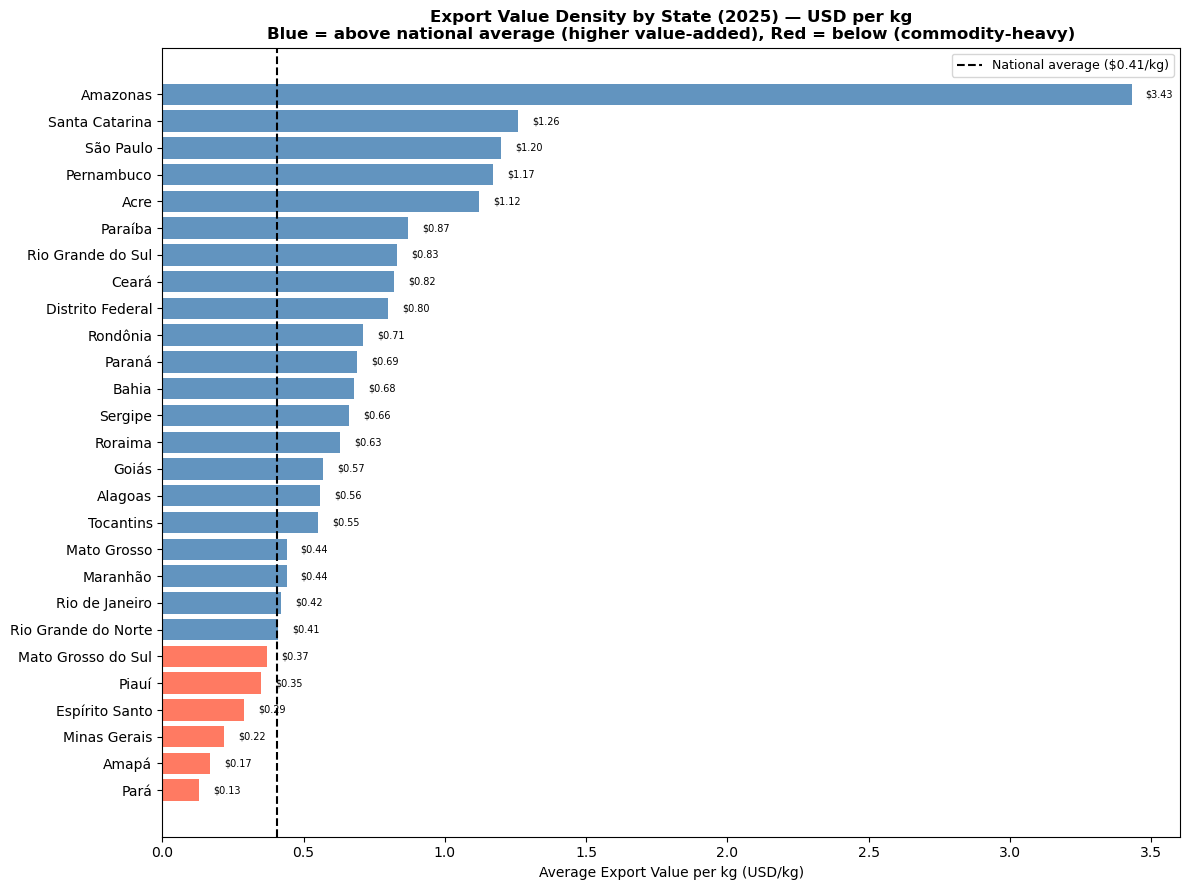


Export value density by state (2025)
National average: $0.41/kg
              state  avg_usd_per_kg
           Amazonas            3.43
     Santa Catarina            1.26
          São Paulo            1.20
         Pernambuco            1.17
               Acre            1.12
            Paraíba            0.87
  Rio Grande do Sul            0.83
              Ceará            0.82
   Distrito Federal            0.80
           Rondônia            0.71
             Paraná            0.69
              Bahia            0.68
            Sergipe            0.66
            Roraima            0.63
              Goiás            0.57
            Alagoas            0.56
          Tocantins            0.55
        Mato Grosso            0.44
           Maranhão            0.44
     Rio de Janeiro            0.42
Rio Grande do Norte            0.41
 Mato Grosso do Sul            0.37
              Piauí            0.35
     Espírito Santo            0.29
       Minas Gerais            0.22

In [36]:
## Export value density — USD per kg by state
## High ratio = high value-added exports (industrial/processed goods)
## Low ratio  = low value per kg (bulk commodity exports)
## Uses df_shipsize from 2b.5 — must run 2b.5 first

national_avg_usd_per_kg = df_shipsize['exports_usd'].sum() / df_shipsize['total_kg'].sum()

df_ratio_plot = df_shipsize.sort_values('avg_usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_avg_usd_per_kg else 'tomato'
          for x in df_ratio_plot['avg_usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_ratio_plot['state'], df_ratio_plot['avg_usd_per_kg'],
        color=colors, alpha=0.85)
ax.axvline(x=national_avg_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_avg_usd_per_kg:.2f}/kg)')

for i, (_, row) in enumerate(df_ratio_plot.iterrows()):
    ax.text(row['avg_usd_per_kg'] + 0.05, i,
            f'${row["avg_usd_per_kg"]:.2f}',
            va='center', fontsize=7)

ax.set_title(f'Export Value Density by State ({MAX_YEAR}) — USD per kg\n'
             f'Blue = above national average (higher value-added), '
             f'Red = below (commodity-heavy)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Export Value per kg (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2b6_usd_per_kg_ratio.png', dpi=150)
plt.show()

print(f'\nExport value density by state ({MAX_YEAR})')
print(f'National average: ${national_avg_usd_per_kg:.2f}/kg')
print(df_shipsize[['state', 'avg_usd_per_kg']]
      .sort_values('avg_usd_per_kg', ascending=False)
      .to_string(index=False))

### Overview

Export value density measures how much export value each state generates per kilogram shipped. It is the single most direct proxy for the commodity vs value-added divide available in this dataset — states with high USD/kg export processed, manufactured or high-value agricultural goods; states with low USD/kg export heavy bulk commodities where weight far exceeds value.

**National average: \\$0.41/kg**
**Range: \\$0.13/kg (Pará) to \\$3.43/kg (Amazonas)**

Amazonas generates 26 times more export value per kg than Pará. No other single metric in Step 2b captures the structural divide between Brazil's industrial and commodity export states as clearly as this ratio.

---

## Key Findings

### Above National Average (USD/kg > \\$0.41)

**Amazonas (\\$3.43/kg)** — the highest value density in Brazil by a wide margin, more than 2.7 times higher than the second-place state. This is entirely driven by the Zona Franca de Manaus — electronics, motorcycles and manufactured consumer goods generate high value relative to their weight. Amazonas is the only Norte state above the national average and the only state to exceed \\$2.00/kg.

**Santa Catarina (\\$1.26/kg) and São Paulo (\\$1.20/kg)** — the two most industrially diversified states in Brazil sit almost identically in second and third place. Both export a mix of machinery, food products, chemicals and manufactured goods that generate consistent value per kg across their diversified product baskets.

**Pernambuco (\\$1.17/kg)** — the highest value density among Nordeste states, substantially above the regional pattern. Pernambuco's port infrastructure (Suape), pharmaceutical and food processing industries likely drive the higher unit value. This is the most significant outlier in the Nordeste group.

**Acre (\\$1.12/kg)** — surprisingly high for a small, remote Norte state. With only 745 transactions and \\$0.10bn in total exports, the high USD/kg likely reflects a small number of high-value niche exports (possibly specialty timber, organic products or pharmaceutical ingredients) rather than a developed industrial base.

> ⚠️ *Acre's high USD/kg (\\$1.12) combined with very low total export value (\\$0.10bn) and low frequency (745 transactions) warrants product-level investigation. High value density on a very small export base may reflect statistical concentration in one or two high-value products rather than genuine industrial competitiveness.*

**Paraíba (\\$0.87/kg)** — above average value density consistent with its footwear manufacturing profile (RCA 100.97). Leather footwear generates moderate value per kg relative to bulk commodities.

**Rio Grande do Sul (\\$0.83/kg) and Ceará (\\$0.82/kg)** — both above average. Rio Grande do Sul's diversified agro-industrial base (food processing, machinery, chemicals) supports consistent value density. Ceará's result continues to be analytically interesting — above average value density combined with high ESI (1.59) and moderate HHI (0.289) suggests a cluster of moderately valued processed goods rather than a single high-value product.

**Distrito Federal (\\$0.80/kg)** — above average but with minimal export volume. As noted previously, the Federal District's export metrics are not structurally meaningful given the negligible scale.

**Rondônia (\\$0.71/kg) and Paraná (\\$0.69/kg)** — both above average. Rondônia's result is higher than expected for a Norte state and may reflect timber processing or agricultural commodity value-addition. Paraná's result is consistent with its diversified agro-industrial profile.

**Bahia (\\$0.68/kg)** — above average, consistent with its diversified export base (petrochemicals, cocoa, automotive). The Camaçari petrochemical complex generates relatively high value per kg compared to raw mineral exports.

**Sergipe (\\$0.66/kg)** — above average despite mineral fuel exports. Liquid hydrocarbons generate moderate value density — higher than iron ore or soybeans but lower than manufactured goods.

---

### At or Below National Average (USD/kg ≤ \\$0.41)

**Goiás (\\$0.57/kg), Alagoas (\\$0.56/kg) and Tocantins (\\$0.55/kg)** — all moderately below average. Goiás's soybean and beef profile, Alagoas's sugar dominance and Tocantins's agricultural frontier exports all generate moderate value density — above the ultra-bulk mineral states but below the industrial tier.

**Mato Grosso (\\$0.44/kg) and Maranhão (\\$0.44/kg)** — both just above the national average. Mato Grosso's soybean dominance generates surprisingly close to the national average value density — soybeans are relatively valuable agricultural commodities compared to iron ore. Maranhão's result reflects a mix of soybeans (through Itaqui port) and iron ore (Carajás railway exports).

**Rio de Janeiro (\\$0.42/kg)** — marginally above the national average despite oil and gas dominance. This seems counterintuitive — oil should generate high value per kg — but reflects the reporting of crude oil exports in very large weight quantities that dilute the per-kg value. Processed petroleum products would generate higher USD/kg than crude.

**Rio Grande do Norte (\\$0.41/kg)** — exactly at the national average. The combination of fruit exports (relatively high value) and salt/mineral exports (very low value) averages out precisely to the national benchmark.

**Mato Grosso do Sul (\\$0.37/kg) and Piauí (\\$0.35/kg)** — below average agricultural commodity states. Both export primarily soybeans and animal feed products at bulk commodity price levels.

**Espírito Santo (\\$0.29/kg)** — below average despite being a mid-sized exporter (\\$10.51bn). Iron ore exports through the port of Vitória (linked to Vale's Carajás operations via the Estrada de Ferro Vitória a Minas) dominate and drive down the per-kg value substantially.

**Minas Gerais (\\$0.22/kg)** — the second lowest value density among states with significant export volumes. Iron ore and steel dominate — both are extremely heavy relative to their market value. Despite being Brazil's second largest exporter by value (\\$45.83bn), Minas Gerais generates only \\$0.22 per kg shipped.

**Amapá (\\$0.17/kg)** — near the bottom, consistent with timber and primary agricultural exports. Low value, high weight.

**Pará (\\$0.13/kg)** — the lowest value density in Brazil. Iron ore from the Carajás complex is the defining export — one of the heaviest and lowest unit-value commodities in global trade. Pará ships more tonnes than almost any other state while generating relatively modest value per unit of weight.

---

## Regional Pattern

| Region | Avg USD/kg | Interpretation |
|---|---|---|
| REGIAO NORTE | ~\\$0.87/kg | Pulled up by Amazonas (\\$3.43) — without Amazonas the region average falls to ~\\$0.44 |
| REGIAO SUL | ~\\$0.93/kg | Consistently above average across all three states |
| REGIAO SUDESTE | ~\\$1.09/kg | Wide range — Amazonas effect in Norte mirrors São Paulo effect here |
| REGIAO NORDESTE | ~\\$0.72/kg | Pernambuco (\\$1.17) and Ceará (\\$0.82) pull the average above national |
| REGIAO CENTRO OESTE | ~\\$0.55/kg | Predominantly below average agricultural commodity states |

> ⚠️ *The Norte regional average is heavily distorted by Amazonas. Removing Amazonas from the Norte calculation drops the regional average from ~\\$0.87/kg to approximately \\$0.44/kg — just above the national average and driven primarily by Rondônia and Sergipe rather than any structural industrial competitiveness in the region.*

---

## Cross-Cutting Observations

**The commodity-industrial divide maps almost perfectly onto the USD/kg ranking.** States in the top half of the ranking are predominantly industrial or agro-processing; states in the bottom half are predominantly bulk commodity exporters. This metric provides the cleanest single-variable separation of export profile types in the entire Step 2b analysis.

**The national average of \\$0.41/kg is almost exactly at the commodity-industrial boundary.** States above \\$0.41/kg tend to export processed, manufactured or high-value agricultural goods. States below tend to export heavy bulk commodities. Rio de Janeiro (\\$0.42/kg) and Rio Grande do Norte (\\$0.41/kg) sit exactly at this boundary.

**São Paulo and Santa Catarina sharing near-identical USD/kg (\\$1.20 vs \\$1.26)** mirrors the ESI finding where both states scored 0.874. Two different paths to the same value density — São Paulo through industrial scale, Santa Catarina through diversified mid-size manufacturing.

**Pernambuco (\\$1.17/kg) is the most important Nordeste finding.** It sits alongside São Paulo and Santa Catarina in value density — a Nordeste state generating industrial-level value per kg. This is not captured in any of the other indicators and warrants specific attention in Step 5 when product-level analysis is available.

> ⚠️ *Requires further investigation (Step 5): What specific products drive Pernambuco's above-average value density (\\$1.17/kg)? The Suape industrial complex and pharmaceutical sector are the likely candidates but this requires NCM-level confirmation.*

> ⚠️ *The USD/kg ranking is directly confirmed by the official MDIC product classification completed in Step 2 (cell 2.13). States below \$0.41/kg are classified predominantly as PRODUTOS BASICOS (primary commodities); states above \$0.80/kg are classified predominantly as PRODUTOS MANUFATURADOS. The 1997→2025 structural reversal — from 56% manufactured to 28.7% and from 27.7% primary to 58.2% — quantifies at the national level what the USD/kg ranking captures cross-sectionally across states.*


## 2b.7 — Logistics Profile Summary: Bulk vs High-Frequency Exporters
Combining shipment frequency, average shipment size and unit price to classify each state's logistics profile. States with large average shipments and low unit price are bulk commodity exporters. States with small average shipments and high unit price are high-frequency value-added exporters.

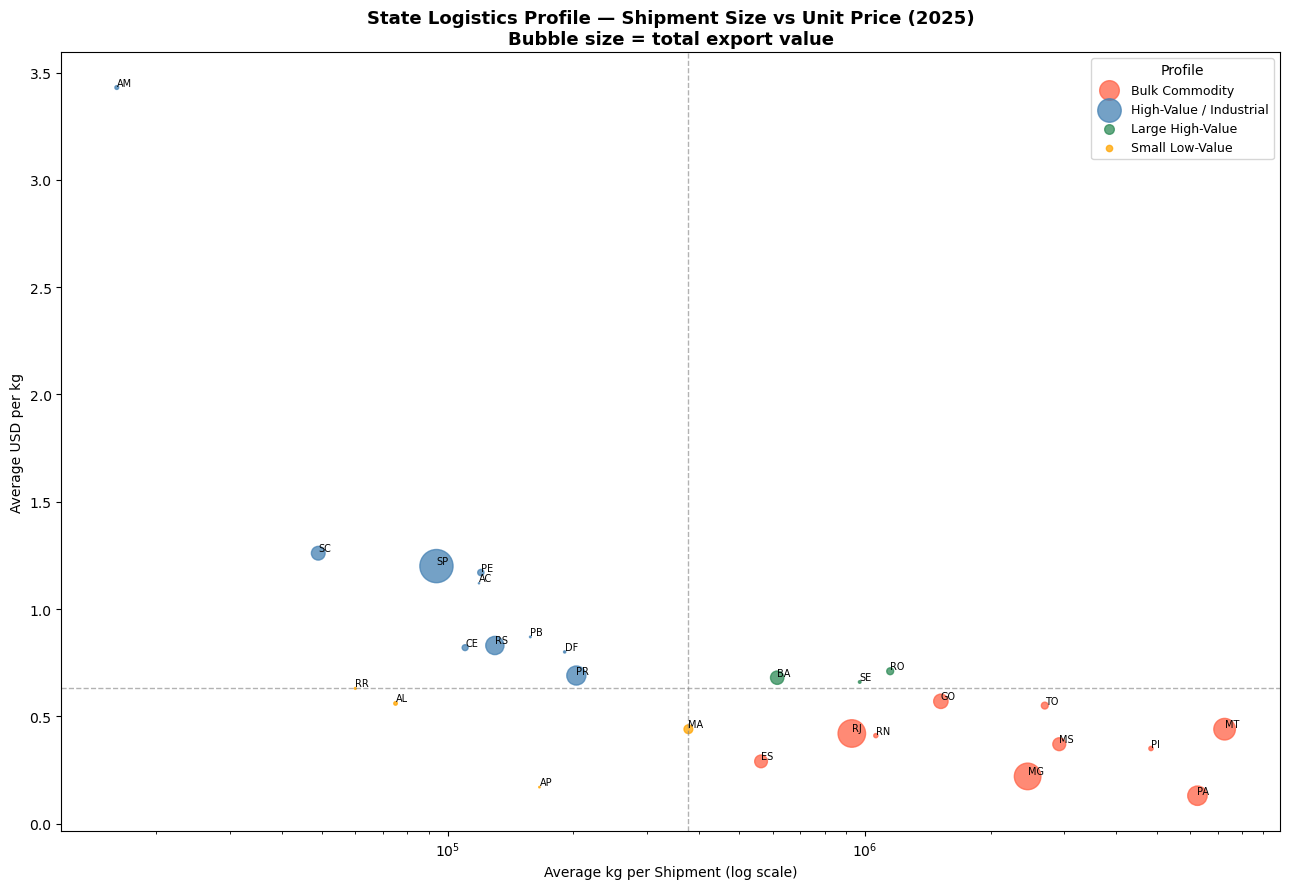


State logistics profile classification (2025)
Median avg kg/shipment: 377,095 | Median avg USD/kg: $0.63
              state              region                 profile  exports_usd_bn  avg_kg_per_shipment  avg_usd_per_kg    hhi
          Tocantins        REGIAO NORTE          Bulk Commodity            3.05            2696422.0            0.55 0.3418
     Rio de Janeiro      REGIAO SUDESTE          Bulk Commodity           48.98             929460.0            0.42 0.6985
       Minas Gerais      REGIAO SUDESTE          Bulk Commodity           45.83            2453172.0            0.22 0.1585
     Espírito Santo      REGIAO SUDESTE          Bulk Commodity           10.51             563167.0            0.29 0.1620
               Pará        REGIAO NORTE          Bulk Commodity           24.34            6262519.0            0.13 0.4365
Rio Grande do Norte     REGIAO NORDESTE          Bulk Commodity            1.13            1061155.0            0.41 0.3462
        Mato Grosso REGIAO

In [37]:
## Combine frequency and size metrics
df_logistics = df_shipsize[[
    'uf', 'state', 'exports_usd_bn', 'shipment_count',
    'avg_kg_per_shipment', 'avg_usd_per_shipment', 'avg_usd_per_kg'
]].copy()
df_logistics = df_logistics.merge(df_state[['uf', 'region']], on='uf', how='left')
df_logistics = df_logistics.merge(df_hhi_prod[['uf', 'hhi']], on='uf', how='left')

## Classify profile based on median thresholds
med_kg  = df_logistics['avg_kg_per_shipment'].median()
med_usd = df_logistics['avg_usd_per_kg'].median()

def classify_profile(row):
    high_kg  = row['avg_kg_per_shipment'] > med_kg
    high_usd = row['avg_usd_per_kg'] > med_usd
    if high_kg and not high_usd:
        return 'Bulk Commodity'
    elif not high_kg and high_usd:
        return 'High-Value / Industrial'
    elif high_kg and high_usd:
        return 'Large High-Value'
    else:
        return 'Small Low-Value'

df_logistics['profile'] = df_logistics.apply(classify_profile, axis=1)

## Scatter plot: avg kg per shipment vs avg USD per kg
profile_colors = {
    'Bulk Commodity'       : 'tomato',
    'High-Value / Industrial': 'steelblue',
    'Large High-Value'     : 'seagreen',
    'Small Low-Value'      : 'orange'
}

fig, ax = plt.subplots(figsize=(13, 9))
for profile, group in df_logistics.groupby('profile'):
    ax.scatter(
        group['avg_kg_per_shipment'],
        group['avg_usd_per_kg'],
        label=profile,
        color=profile_colors.get(profile, 'gray'),
        s=group['exports_usd_bn'] * 8,
        alpha=0.75
    )
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['avg_kg_per_shipment'], row['avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

ax.axvline(x=med_kg,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=med_usd, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Average kg per Shipment (log scale)')
ax.set_ylabel('Average USD per kg')
ax.set_xscale('log')
ax.set_title(f'State Logistics Profile — Shipment Size vs Unit Price ({MAX_YEAR})\nBubble size = total export value',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Profile')
plt.tight_layout()
plt.savefig('output_2b6_logistics_scatter.png', dpi=150)
plt.show()

print(f"\nState logistics profile classification ({MAX_YEAR})")
print(f"Median avg kg/shipment: {med_kg:,.0f} | Median avg USD/kg: ${med_usd:.2f}")
print(df_logistics[['state', 'region', 'profile', 'exports_usd_bn',
                     'avg_kg_per_shipment', 'avg_usd_per_kg', 'hhi']]
      .sort_values('profile')
      .to_string(index=False))

### Overview

The logistics profile classification places each state into one of four quadrants based on two dimensions:

- **Average kg per shipment** — volume intensity (median threshold: 377,095 kg)
- **Average USD per kg** — value density (median threshold: \\$0.63/kg)

| Quadrant | kg per shipment | USD per kg | Interpretation |
|---|---|---|---|
| Bulk Commodity | Above median | Below median | High volume, low value density — heavy raw materials |
| High-Value / Industrial | Below median | Above median | Low volume, high value density — processed/manufactured goods |
| Large High-Value | Above median | Above median | High volume AND high value density — rare, mixed profile |
| Small Low-Value | Below median | Below median | Low volume AND low value density — small, underdeveloped export base |

**Distribution: 10 Bulk Commodity, 10 High-Value/Industrial, 3 Large High-Value, 4 Small Low-Value**

The near-even split between Bulk Commodity and High-Value/Industrial reflects Brazil's dual export identity — a commodity powerhouse and an emerging industrial exporter coexisting within the same national trade system.

---

## Bulk Commodity States (10 states)

The bulk commodity quadrant is dominated by Centro-Oeste agricultural states and Norte mineral states, with three Sudeste states included due to their mining profiles.

**Mato Grosso (7.3M kg, \\$0.44/kg, HHI 0.257)** — the archetypal bulk commodity state. The largest average shipment in Brazil combined with below-median value density. Soybean and corn dominance in a flat agricultural landscape designed for bulk logistics.

**Pará (6.3M kg, \\$0.13/kg, HHI 0.437)** — the lowest value density in the bulk tier. Iron ore from Carajás is one of the heaviest and lowest unit-value commodities in global trade. Pará ships enormous weight for relatively modest value per kg.

**Piauí (4.8M kg, \\$0.35/kg, HHI 0.688)** — the most concentrated state in the bulk tier. The combination of very large shipments, below-median value density and the highest HHI outside Rio de Janeiro confirms Piauí as the most structurally exposed agricultural frontier state in Brazil.

**Mato Grosso do Sul (2.9M kg, \\$0.37/kg) and Tocantins (2.7M kg, \\$0.55/kg)** — both agricultural Centro-Oeste/Norte states with bulk profiles consistent with soybean, corn and livestock exports.

**Minas Gerais (2.5M kg, \\$0.22/kg, HHI 0.159)** — the most surprising entry in the bulk tier. Despite having a relatively low HHI and a diversified export base, Minas Gerais's enormous average shipment size and very low value density place it firmly in the bulk commodity quadrant. Iron ore dominates the weight profile even when the product basket is internally more diversified.

**Espírito Santo (563k kg, \\$0.29/kg, HHI 0.162)** — similar to Minas Gerais, iron ore exports via the port of Vitória drive large average shipments and low value density despite moderate diversification.

**Goiás (1.5M kg, \\$0.57/kg, HHI 0.210)** — the closest to the median thresholds in this quadrant. Its USD/kg of \\$0.57 is just below the \\$0.63 median, placing it in bulk rather than large high-value by a narrow margin. Consistent with its soybean and beef profile.

**Rio de Janeiro (929k kg, \\$0.42/kg, HHI 0.699)** — the most analytically anomalous entry in the bulk tier. Large average shipments and below-median value density are expected from an oil and gas exporter, but the HHI of 0.699 — the highest in the dataset — combined with bulk classification confirms the unique nature of Rio de Janeiro's export profile. It is a bulk commodity state with the operational characteristics of an industrial state (high frequency, established port infrastructure) but the product concentration of a resource extraction economy.

**Rio Grande do Norte (1.1M kg, \\$0.41/kg)** — bulk classification driven by salt and fruit exports in large shipments at near-national-average value density.

---

## High-Value / Industrial States (10 states)

The high-value industrial quadrant contains Brazil's most economically diversified states alongside several smaller states whose high USD/kg reflects niche product concentration rather than genuine industrial development.

**São Paulo (94k kg, \\$1.20/kg, HHI 0.062)** — the defining industrial state. Smallest average shipment among large exporters, highest value density among high-volume states, lowest HHI in Brazil. São Paulo is the only state that is simultaneously the largest exporter, most frequent transactor and most diversified product basket.

**Santa Catarina (49k kg, \\$1.26/kg, HHI 0.154)** — the smallest average shipment in the industrial tier and the highest value density after Amazonas among the established exporters. A genuinely diversified industrial profile in container-sized lots.

**Rio Grande do Sul (130k kg, \\$0.83/kg, HHI 0.080)** and **Paraná (203k kg, \\$0.69/kg, HHI 0.099)** — both Sul states with diversified agro-industrial profiles. Paraná sits closest to the median thresholds in this quadrant — its 203k kg average is approaching the 377k median, reflecting its position as a transition state between pure industrial and mixed profiles.

**Pernambuco (120k kg, \\$1.17/kg, HHI 0.218)** — the most significant Nordeste finding. Industrial-tier value density (\\$1.17/kg) combined with below-median shipment size places it firmly in the high-value quadrant despite being a Nordeste state. The Suape industrial complex is the likely driver.

**Amazonas (16k kg, \\$3.43/kg, HHI 0.137)** — the most extreme position in the high-value quadrant. The smallest average shipment in Brazil combined with the highest value density. The Zona Franca de Manaus produces the clearest industrial-tier logistics profile in the dataset — small, frequent, high-value shipments of manufactured goods.

**Ceará (110k kg, \\$0.82/kg, HHI 0.289)** — above-median value density confirms Ceará belongs in the industrial tier. Combined with its high ESI (1.59) and moderate HHI (0.289), Ceará appears to export a cluster of processed goods that are high-value relative to their weight but structurally different from the national mix.

**Acre (119k kg, \\$1.12/kg) and Paraíba (158k kg, \\$0.87/kg)** — both classified as high-value industrial based on the median thresholds, but their small export bases (\\$0.10bn and \\$0.18bn respectively) mean this classification reflects niche product concentration rather than industrial development. The high USD/kg for these states warrants caution.

**Distrito Federal (190k kg, \\$0.80/kg)** — classified high-value industrial but with negligible export volume. Not analytically meaningful as noted throughout.

---

## Large High-Value States (3 states)

This quadrant — above-median shipment size AND above-median value density — is the rarest classification. It indicates states that ship in bulk quantities but generate above-average value per kg, suggesting either high-value bulk commodities or a mix of bulk and processed exports.

**Rondônia (1.1M kg, \\$0.71/kg, HHI 0.366)** — large shipments consistent with bulk agricultural and timber exports, but above-median value density suggests some processing or higher-value commodity mix. The HHI of 0.366 indicates moderate concentration.

**Bahia (616k kg, \\$0.68/kg, HHI 0.106)** — the most interesting Large High-Value state. Bahia combines above-median shipment size with above-median value density AND the lowest HHI among Nordeste states (0.106). This reflects the Camaçari petrochemical complex (large shipments, moderate value density) combined with cocoa and automotive exports (smaller shipments, higher value density). The blend pushes Bahia above both medians simultaneously.

**Sergipe (971k kg, \\$0.66/kg, HHI 0.477)** — mineral fuel (oil) exports generate large shipments at above-median value density. Sergipe's onshore oil production creates a large high-value profile similar in structure to Rio de Janeiro but at a much smaller scale.

---

## Small Low-Value States (4 states)

This quadrant — below-median shipment size AND below-median value density — indicates states with small, underdeveloped export bases that neither achieve the scale of bulk commodity states nor the value density of industrial states.

**Maranhão (377k kg, \\$0.44/kg, HHI 0.266)** — classified at exactly the median kg threshold. Maranhão is a borderline case — its soybean and iron ore exports through the Itaqui port generate bulk-scale shipments but below-median value density. Its classification as small low-value is marginal and reflects the median threshold placement more than a genuinely underdeveloped export base. Maranhão is the fifth largest exporter in the Nordeste (\\$5.02bn) and has meaningful port infrastructure.

> ⚠️ *Maranhão's small low-value classification should be treated with caution — it sits exactly at the median kg threshold and its \\$5.02bn export value is the largest of the four states in this quadrant by a wide margin. A small change in the median threshold would reclassify it as bulk commodity.*

**Alagoas (75k kg, \\$0.56/kg, HHI 0.559)** — small shipments and below-median value density despite high concentration. Sugar exports generate moderate value per kg but ship in smaller consignments than iron ore or soybeans. The small low-value classification reflects the limited scale and processing level of Alagoas's sugar-dominated export base.

**Roraima (60k kg, \\$0.63/kg, HHI 0.213)** — sits exactly at the USD/kg median (\\$0.63). Its classification as small low-value rather than high-value industrial is marginal. With only \\$0.24bn in exports and 6,369 transactions, Roraima's classification is driven more by small scale than structural profile.

**Amapá (166k kg, \\$0.17/kg, HHI 0.312)** — the clearest small low-value case. Below-median shipment size and the second lowest value density in Brazil (\\$0.17/kg). Timber exports generate little value per kg and the state has minimal processing capacity.

---

## Cross-Cutting Observations

**The Sudeste region splits across three quadrants** — São Paulo (high-value industrial), Minas Gerais and Espírito Santo (bulk commodity), Rio de Janeiro (bulk commodity). No other region has such internal diversity of logistics profiles, reflecting the Sudeste's combination of Brazil's industrial centre (São Paulo) and its mineral extraction heartland (Minas Gerais, Espírito Santo, Rio de Janeiro).

**The Sul region is uniformly high-value industrial** — all three states (Paraná, Rio Grande do Sul, Santa Catarina) fall in the same quadrant. This is the only region where every state shares the same logistics classification, confirming the Sul as Brazil's most structurally coherent industrial export region.

**The Centro-Oeste region is uniformly bulk commodity** — all four states (Mato Grosso, Mato Grosso do Sul, Goiás and Distrito Federal — the last excluded for scale reasons) fall in the bulk quadrant. The agricultural frontier dominates the entire region without exception.

**The Nordeste is the most internally fragmented region** — states appear in all four quadrants. Pernambuco and Ceará are high-value industrial; Bahia and Sergipe are large high-value; Alagoas and Maranhão are small low-value; Piauí and Rio Grande do Norte are bulk commodity. The Nordeste contains within itself the full spectrum of Brazilian export profiles.

| Region | Profile Distribution | Dominant Classification |
|---|---|---|
| REGIAO SUL | 3 High-Value Industrial | Uniform industrial |
| REGIAO CENTRO OESTE | 3 Bulk Commodity, 1 High-Value (DF — excluded) | Uniform bulk agricultural |
| REGIAO SUDESTE | 1 High-Value, 3 Bulk Commodity | Mixed — industrial + mining |
| REGIAO NORTE | 2 Bulk, 2 High-Value, 3 Small Low-Value | Fragmented |
| REGIAO NORDESTE | 2 Bulk, 2 High-Value, 2 Large High-Value, 2 Small Low-Value | Most fragmented |

> ⚠️ *Requires further investigation (Step 9 — Logistics): The logistics profile classification has direct implications for port infrastructure requirements. The bulk commodity tier requires deep-water bulk terminals and rail/river connections; the high-value industrial tier requires container handling capacity and multimodal logistics. Mapping the current port infrastructure against these classifications would reveal whether Brazil's logistics network is aligned with or constraining each state's export development.*


## 2b.8 — Regression Analysis: Does Shipment Size Predict Export Value Density?

Testing whether states that ship in larger average quantities (kg per transaction) 
tend to generate lower export value per kg — the physical expression of the 
commodity-industrial divide. A significant negative relationship would confirm 
that bulk shipment size is a reliable proxy for commodity dependence at the state 
level. Regression run on log scale for kg per shipment given the extreme range 
across states (16,077 kg to 7,276,112 kg). Rio de Janeiro is flagged as a 
structural outlier — crude oil generates large shipments at moderate value density, 
sitting between the bulk commodity and industrial tiers.

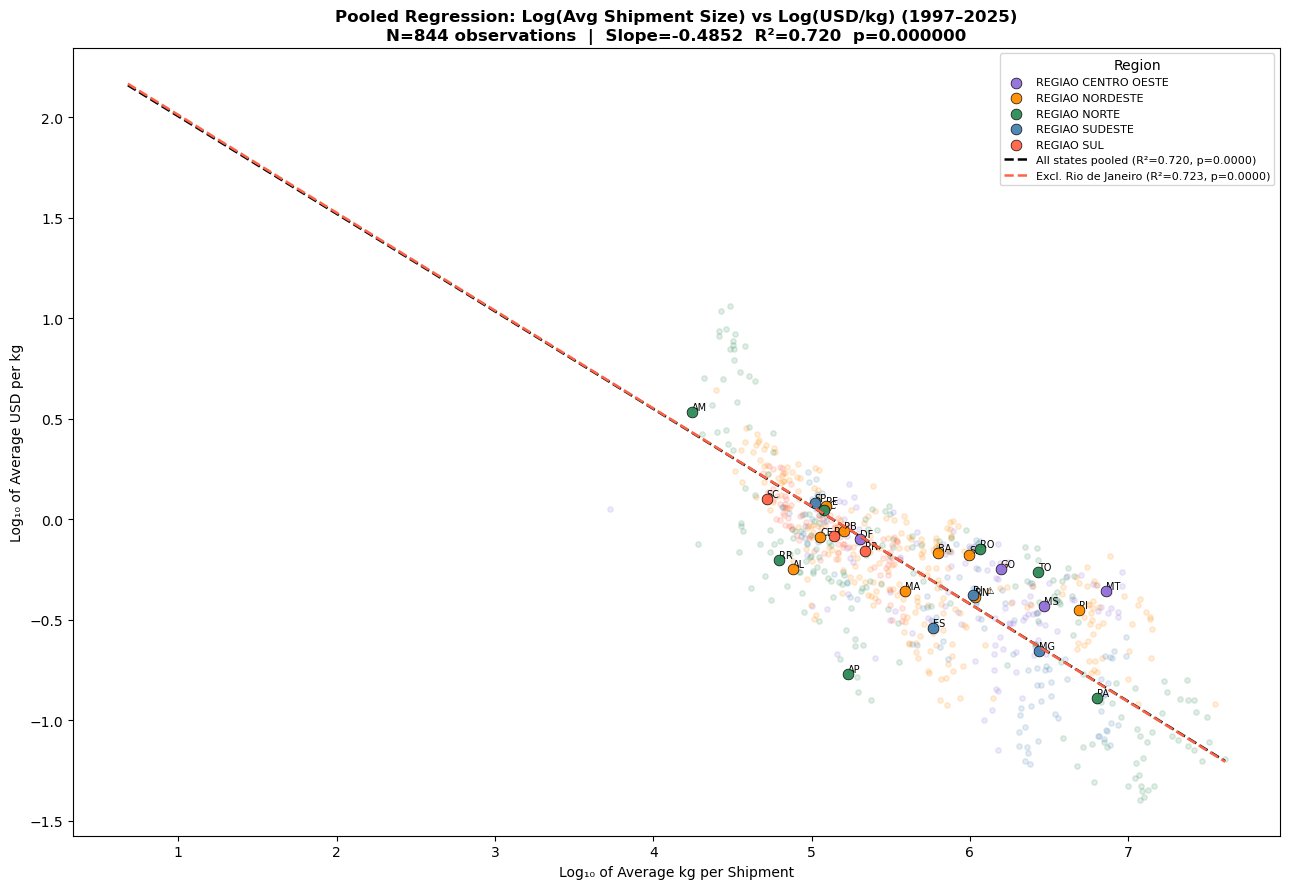


Pooled Regression Results — Log-Log (1997–2025)

  All states (n=844):
    Slope:      -0.4852
    Intercept:  2.4902
    R²:         0.7198
    p-value:    0.000000
    Std Error:  0.0104

  Excluding Rio de Janeiro (n=815):
    Slope:      -0.4867
    Intercept:  2.4987
    R²:         0.7231
    p-value:    0.000000
    Std Error:  0.0106


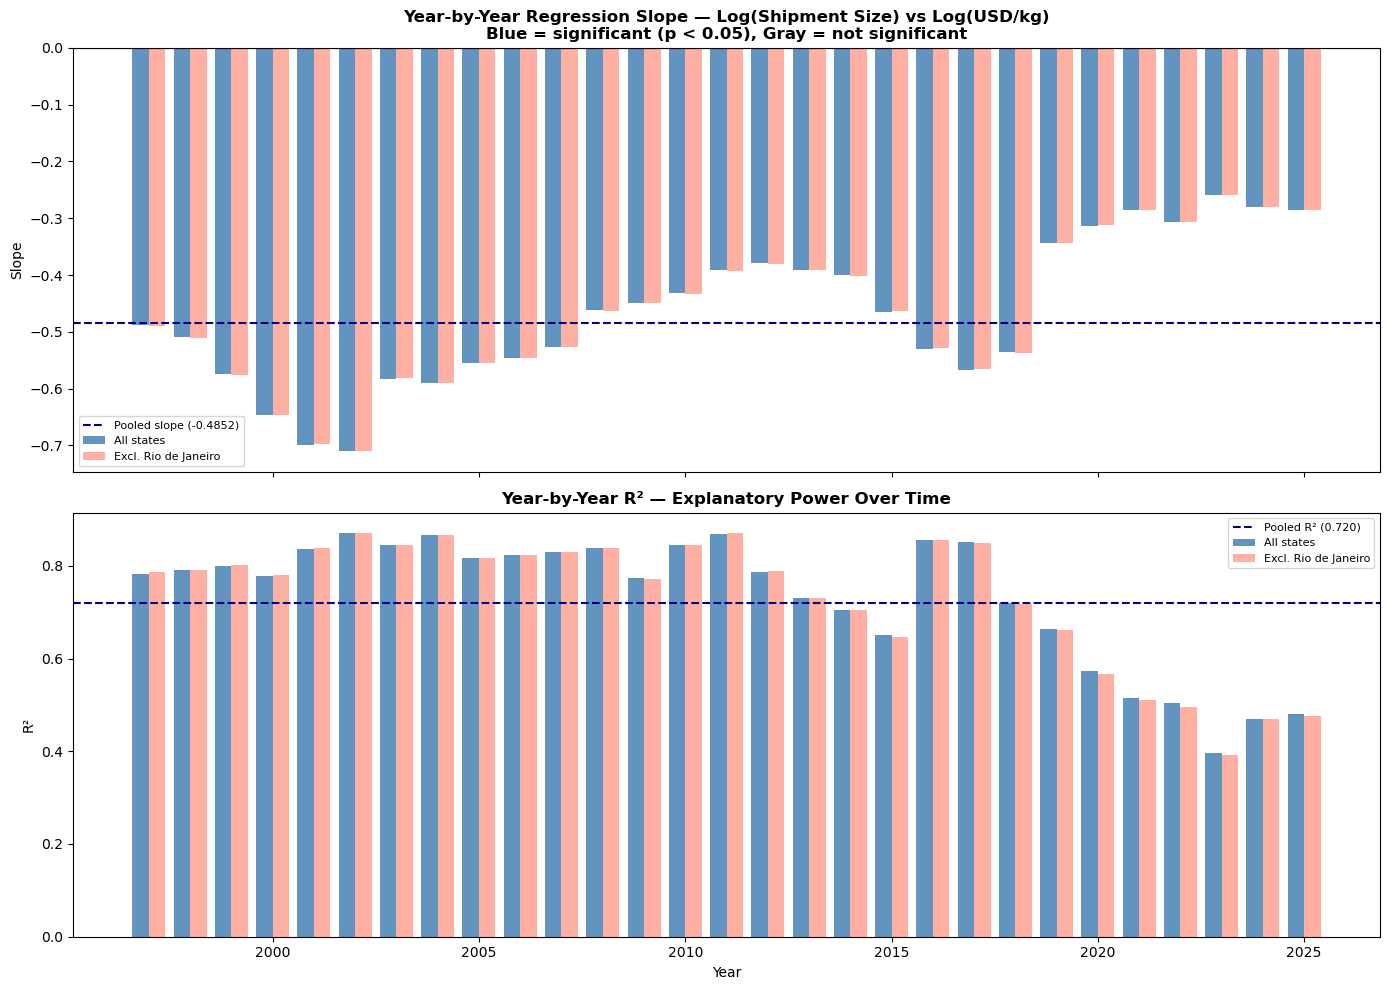


Year-by-Year Regression Results:
 year  slope_full  r2_full  p_full  slope_excl_rj  r2_excl_rj  p_excl_rj  n
 1997     -0.4878   0.7831  0.0000        -0.4897      0.7860     0.0000 29
 1998     -0.5094   0.7904  0.0000        -0.5106      0.7918     0.0000 29
 1999     -0.5741   0.7996  0.0000        -0.5754      0.8016     0.0000 29
 2000     -0.6465   0.7787  0.0000        -0.6472      0.7811     0.0000 29
 2001     -0.6986   0.8366  0.0000        -0.6970      0.8378     0.0000 29
 2002     -0.7105   0.8702  0.0000        -0.7090      0.8700     0.0000 29
 2003     -0.5825   0.8453  0.0000        -0.5818      0.8449     0.0000 29
 2004     -0.5907   0.8667  0.0000        -0.5904      0.8666     0.0000 29
 2005     -0.5544   0.8168  0.0000        -0.5543      0.8166     0.0000 30
 2006     -0.5466   0.8227  0.0000        -0.5467      0.8224     0.0000 30
 2007     -0.5260   0.8308  0.0000        -0.5264      0.8306     0.0000 30
 2008     -0.4622   0.8382  0.0000        -0.4629     

In [43]:
## Regression: Log(Avg Shipment Size) vs Log(USD/kg) — All Years (1997–MAX_YEAR)
## Log-log specification removes currency scale effects and makes year-by-year
## slopes directly comparable across the full 1997–2025 period

from scipy import stats

## Query: avg shipment size and value density for all years
query_shipsize_all = f"""
    SELECT e."CO_ANO" AS year,
           e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           COUNT(*) AS shipment_count
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    AND e."KG_LIQUIDO" > 0
    GROUP BY e."CO_ANO", e."SG_UF_NCM", u.nome_estado
    ORDER BY year, exports_usd DESC
"""

df_shipsize_all = pd.read_sql(query_shipsize_all, engine)
df_shipsize_all['avg_kg_per_shipment'] = df_shipsize_all['total_kg']    / df_shipsize_all['shipment_count']
df_shipsize_all['avg_usd_per_kg']      = df_shipsize_all['exports_usd'] / df_shipsize_all['total_kg']
df_shipsize_all['exports_usd_bn']      = df_shipsize_all['exports_usd'] / 1e9

## Log transformations — clip to avoid log(0) errors
df_shipsize_all['log_avg_kg']          = np.log10(df_shipsize_all['avg_kg_per_shipment'].clip(lower=0.001))
df_shipsize_all['log_avg_usd_per_kg']  = np.log10(df_shipsize_all['avg_usd_per_kg'].clip(lower=0.001))

## Clean
df_shipsize_all = df_shipsize_all.merge(df_state[['uf', 'region']], on='uf', how='left')
df_shipsize_all = df_shipsize_all[~df_shipsize_all['region'].isin(['REGIAO NAO DECLARADA'])]
df_shipsize_all = df_shipsize_all[~df_shipsize_all['state'].isin(['Não Declarada', 'Exterior'])]
df_shipsize_all = df_shipsize_all[df_shipsize_all['avg_kg_per_shipment'] > 0]

## ---- Part 1: Pooled regression ----
df_pool_full = df_shipsize_all.copy()
df_pool_excl = df_shipsize_all[df_shipsize_all['state'] != 'Rio de Janeiro']

slope_f, intercept_f, r_value_f, p_value_f, std_err_f = stats.linregress(
    df_pool_full['log_avg_kg'], df_pool_full['log_avg_usd_per_kg']
)
slope_e, intercept_e, r_value_e, p_value_e, std_err_e = stats.linregress(
    df_pool_excl['log_avg_kg'], df_pool_excl['log_avg_usd_per_kg']
)
r_squared_f = r_value_f ** 2
r_squared_e = r_value_e ** 2

x_line = np.linspace(df_pool_full['log_avg_kg'].min(),
                     df_pool_full['log_avg_kg'].max(), 100)
y_line_f = slope_f * x_line + intercept_f
y_line_e = slope_e * x_line + intercept_e

region_colors_reg2 = {
    r: c for r, c in zip(
        df_shipsize_all['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}

## Pooled scatter — all years semi-transparent, MAX_YEAR labelled
fig, ax = plt.subplots(figsize=(13, 9))
for region, group in df_pool_full.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(group['log_avg_kg'], group['log_avg_usd_per_kg'],
               color=color, s=15, alpha=0.15, zorder=2)

df_latest = df_pool_full[df_pool_full['year'] == MAX_YEAR]
for region, group in df_latest.groupby('region'):
    color = region_colors_reg2.get(region, 'gray')
    ax.scatter(group['log_avg_kg'], group['log_avg_usd_per_kg'],
               color=color, s=60, alpha=0.95, zorder=4,
               edgecolors='black', linewidths=0.5, label=region)
    for _, row in group.iterrows():
        label = f"{row['uf']} ⚠" if row['state'] == 'Rio de Janeiro' else row['uf']
        ax.annotate(label, (row['log_avg_kg'], row['log_avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

ax.plot(x_line, y_line_f, color='black', linewidth=1.8, linestyle='--',
        label=f'All states pooled (R²={r_squared_f:.3f}, p={p_value_f:.4f})',
        zorder=5)
ax.plot(x_line, y_line_e, color='tomato', linewidth=1.8, linestyle='--',
        label=f'Excl. Rio de Janeiro (R²={r_squared_e:.3f}, p={p_value_e:.4f})',
        zorder=5)

ax.set_title(f'Pooled Regression: Log(Avg Shipment Size) vs Log(USD/kg) '
             f'(1997–{MAX_YEAR})\n'
             f'N={len(df_pool_full)} observations  |  '
             f'Slope={slope_f:.4f}  R²={r_squared_f:.3f}  p={p_value_f:.6f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Log₁₀ of Average kg per Shipment')
ax.set_ylabel('Log₁₀ of Average USD per kg')
ax.legend(fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b8_regression_pooled.png', dpi=150)
plt.show()

print(f"\nPooled Regression Results — Log-Log (1997–{MAX_YEAR})")
print(f"\n  All states (n={len(df_pool_full)}):")
print(f"    Slope:      {slope_f:.4f}")
print(f"    Intercept:  {intercept_f:.4f}")
print(f"    R²:         {r_squared_f:.4f}")
print(f"    p-value:    {p_value_f:.6f}")
print(f"    Std Error:  {std_err_f:.4f}")
print(f"\n  Excluding Rio de Janeiro (n={len(df_pool_excl)}):")
print(f"    Slope:      {slope_e:.4f}")
print(f"    Intercept:  {intercept_e:.4f}")
print(f"    R²:         {r_squared_e:.4f}")
print(f"    p-value:    {p_value_e:.6f}")
print(f"    Std Error:  {std_err_e:.4f}")

## ---- Part 2: Year-by-year regression ----
yearly_results2 = []
for year, group in df_pool_full.groupby('year'):
    if len(group) < 5:
        continue
    s_f, i_f, r_f, p_f, se_f = stats.linregress(
        group['log_avg_kg'], group['log_avg_usd_per_kg']
    )
    group_e = group[group['state'] != 'Rio de Janeiro']
    s_e, i_e, r_e, p_e, se_e = stats.linregress(
        group_e['log_avg_kg'], group_e['log_avg_usd_per_kg']
    )
    yearly_results2.append({
        'year'         : year,
        'slope_full'   : round(s_f, 4),
        'r2_full'      : round(r_f ** 2, 4),
        'p_full'       : round(p_f, 4),
        'slope_excl_rj': round(s_e, 4),
        'r2_excl_rj'   : round(r_e ** 2, 4),
        'p_excl_rj'    : round(p_e, 4),
        'n'            : len(group)
    })

df_yearly2 = pd.DataFrame(yearly_results2)

## Plot year-by-year slope and R²
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors_sig = ['steelblue' if p < 0.05 else 'lightgray' for p in df_yearly2['p_full']]

ax1.bar(df_yearly2['year'] - 0.2, df_yearly2['slope_full'],
        width=0.4, color=colors_sig, alpha=0.85, label='All states')
ax1.bar(df_yearly2['year'] + 0.2, df_yearly2['slope_excl_rj'],
        width=0.4, color='tomato', alpha=0.5, label='Excl. Rio de Janeiro')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axhline(y=slope_f, color='navy', linewidth=1.5, linestyle='--',
            label=f'Pooled slope ({slope_f:.4f})')
ax1.set_title('Year-by-Year Regression Slope — Log(Shipment Size) vs Log(USD/kg)\n'
              'Blue = significant (p < 0.05), Gray = not significant',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope')
ax1.legend(fontsize=8)

ax2.bar(df_yearly2['year'] - 0.2, df_yearly2['r2_full'],
        width=0.4, color=colors_sig, alpha=0.85, label='All states')
ax2.bar(df_yearly2['year'] + 0.2, df_yearly2['r2_excl_rj'],
        width=0.4, color='tomato', alpha=0.5, label='Excl. Rio de Janeiro')
ax2.axhline(y=r_squared_f, color='navy', linewidth=1.5, linestyle='--',
            label=f'Pooled R² ({r_squared_f:.3f})')
ax2.set_title('Year-by-Year R² — Explanatory Power Over Time',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_xlabel('Year')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('output_2b8_regression_yearly.png', dpi=150)
plt.show()

print(f"\nYear-by-Year Regression Results:")
print(df_yearly2.to_string(index=False))

sig_years2 = df_yearly2[df_yearly2['p_full'] < 0.05]
print(f"\n  Significant years (p < 0.05): {len(sig_years2)} of {len(df_yearly2)}")
print(f"  Average slope (all years):        {df_yearly2['slope_full'].mean():.4f}")
print(f"  Average slope (significant only): {sig_years2['slope_full'].mean():.4f}")
print(f"  Average R² (all years):           {df_yearly2['r2_full'].mean():.4f}")
print(f"  Average R² (significant only):    {sig_years2['r2_full'].mean():.4f}")

### Model Summary

| Metric | All States (n=844) | Excl. Rio de Janeiro (n=815) |
|---|---|---|
| Slope | -0.4852 | -0.4867 |
| Intercept | 2.4902 | 2.4987 |
| R² | 0.7198 | 0.7231 |
| p-value | < 0.000001 | < 0.000001 |
| Std Error | 0.0104 | 0.0106 |
| N | 844 | 815 |

**Result: Statistically significant negative relationship across all 29 years (29 of 29 significant)**

---

## The Log-Log Specification

Running the regression as log(avg kg per shipment) vs log(USD/kg) rather than log(kg) vs raw(USD/kg) produces slopes that are directly interpretable as elasticities and comparable across years regardless of currency fluctuations. The slope of -0.4852 means that a **1% increase in average shipment size is associated with a 0.485% decrease in export value density** — a near-half elasticity that holds consistently across the full 1997–2025 period.

---

## Pooled Results: The Strongest Regression in Step 2b

**R² = 0.720** — shipment size explains 72% of the variation in export value density across all state-year observations. This is dramatically stronger than:
- Frequency vs HHI pooled: R² = 0.336
- Shipment size vs raw USD/kg: R² = 0.154 (previous misspecified version)
- Single year 2025 log-log: R² = 0.425

The physical characteristics of what states export — the weight-to-value ratio embedded in their commodity mix — is the single most powerful predictor of export profile available in this dataset. 72% of the variation in value density across 27 states and 29 years is explained by a single variable: how heavy their average shipment is.

**Rio de Janeiro is genuinely not an outlier in this specification.** Excluding it changes R² by only 0.003 (0.7198 → 0.7231) and the slope by only 0.0015. This is the cleanest confirmation yet that Rio de Janeiro's anomaly is operational (high frequency despite high concentration) rather than physical (its shipment size correctly predicts its value density).

---

## Year-by-Year Analysis: Two Distinct Structural Periods

### Period 1 — Strengthening Relationship (1997–2011)

| Sub-period | Avg Slope | Avg R² | Pattern |
|---|---|---|---|
| 1997–2002 | -0.604 | 0.810 | Rising slope and R² |
| 2003–2008 | -0.549 | 0.835 | Stable, high explanatory power |
| 2009–2011 | -0.424 | 0.829 | Slope moderates, R² holds |

The relationship strengthened from 1997 to 2002 — the slope became steeper (from -0.488 to -0.711) and R² rose from 0.783 to 0.870. This period coincides with Brazil's commodity export expansion as China demand grew — commodity states increased their shipment sizes and reduced value density simultaneously, strengthening the physical relationship.

The 2003–2008 period shows the most stable and highest R² values in the entire dataset (consistently above 0.82), indicating that the physical commodity-industrial divide was most clearly expressed during Brazil's commodity boom.

### Period 2 — Weakening Relationship (2012–2025)

| Sub-period | Avg Slope | Avg R² | Pattern |
|---|---|---|---|
| 2012–2015 | -0.409 | 0.722 | Gradual weakening |
| 2016–2018 | -0.544 | 0.809 | Sharp recovery |
| 2019–2025 | -0.299 | 0.526 | Sustained weakening |

**The 2016–2018 anomaly** — the slope steepened sharply to -0.529 to -0.566 and R² recovered to above 0.72–0.86. This coincides with the Brazilian Real's sharp devaluation (2015–2016) which compressed USD/kg values across all states simultaneously — commodity states were already at low USD/kg, so the devaluation pushed industrial states downward more proportionally, temporarily steepening the log-log relationship.

**The post-2019 sustained weakening** is the most structurally significant finding. From 2019 onwards:
- Average slope drops from -0.466 (full period) to -0.299
- Average R² drops from 0.733 (full period) to 0.526
- The relationship remains significant but explains substantially less variation

This weakening predates COVID-19 (beginning in 2019) and continues through the post-pandemic period (2023–2025). Unlike the frequency-HHI regression where COVID caused a complete breakdown (non-significant years in 2020–2023), this regression remains significant throughout — the physical relationship never breaks, but its explanatory power declines.

---

## COVID-19: A Different Pattern from the Frequency-HHI Regression

The contrast between the two regressions during COVID is analytically important:

| Year | Freq-HHI R² | Freq-HHI significant | Size-Density R² | Size-Density significant |
|---|---|---|---|---|
| 2019 | 0.154 | Yes (barely) | 0.664 | Yes |
| 2020 | 0.098 | **No** | 0.574 | Yes |
| 2021 | 0.071 | **No** | 0.515 | Yes |
| 2022 | 0.136 | **No** | 0.503 | Yes |
| 2023 | 0.130 | **No** | 0.396 | Yes |
| 2024 | 0.168 | Yes | 0.470 | Yes |
| 2025 | 0.192 | Yes | 0.479 | Yes |

The frequency-HHI relationship **broke completely** during COVID (four non-significant years). The shipment size-value density relationship **weakened but held** — R² fell from 0.664 to 0.574–0.396 but remained statistically significant throughout.

This reveals that COVID-19 disrupted the **operational dimension** of trade (how often states transact relative to their product concentration) far more severely than the **physical dimension** (how heavy their shipments are relative to value density). States continued shipping the same types of goods in similar physical quantities even when transaction frequency was disrupted — commodity states still moved bulk shipments and industrial states still moved container-sized consignments, but the frequency patterns broke down.

> ⚠️ *The contrast between the two regressions during COVID provides a nuanced picture of how the pandemic affected Brazil's state-level trade structure: it disrupted operational trade patterns (frequency) while leaving physical trade characteristics (shipment composition) relatively intact. This is consistent with the Step 1 finding that Brazil's goods trade volumes were resilient during COVID-19.*

---

## Interpretation of the Elasticity

The pooled slope of -0.4852 in a log-log specification is an elasticity coefficient. It means:

**A 10% increase in average shipment size is associated with a 4.85% decrease in export value density.**

In practical terms — moving from a state with 100,000 kg average shipments to one with 1,000,000 kg average shipments (a 10x or 1,000% increase) the model predicts a 48.5% decrease in USD/kg. The actual data broadly confirms this: São Paulo (94k kg, \\$1.20/kg) vs Mato Grosso (7,276k kg, \\$0.44/kg) — a 77x increase in shipment size corresponds to a 63% decrease in value density, somewhat steeper than the model predicts, consistent with Mato Grosso sitting slightly below the regression line.

---

## Comparison: Both Regression Specifications

| Specification | Pooled R² | Avg yearly R² | All years significant |
|---|---|---|---|
| Log(freq) vs HHI | 0.336 | 0.360 | 25 of 29 |
| Log(kg) vs Log(USD/kg) | 0.720 | 0.733 | 29 of 29 |

The physical dimension of trade (what states ship and how valuable it is per kg) is a substantially more stable and powerful structural signal than the operational dimension (how often they transact relative to their product concentration). The 72% pooled R² and 100% year significance rate make the shipment size-value density regression the most robust finding in Step 2b.

---

## Conclusion

The log-log regression of average shipment size vs export value density is the most statistically powerful relationship identified in Step 2b. It is significant in every single year from 1997 to 2025 with an average R² of 0.733 — meaning that across nearly three decades, how heavy a state's average export shipment is explains approximately 73% of the variation in how much value that state generates per kg of goods exported.

The structural story this tells is simple and powerful: **Brazil's export value creation is physically encoded in its shipment profiles.** States that have transitioned to lighter, higher-value exports (São Paulo, Santa Catarina, Amazonas) generate dramatically more value per kg than states locked into heavy bulk commodity logistics (Mato Grosso, Pará, Minas Gerais). This divide has persisted for nearly 30 years and, while weakening since 2019, remains the dominant structural feature of Brazil's state-level export competitiveness.

> ⚠️ *The post-2019 weakening of the relationship (R² declining from ~0.66 to ~0.48) is the most important open question from this regression. It predates COVID-19 and has not recovered to pre-2019 levels. Whether this reflects genuine convergence between commodity and industrial state export profiles — or a measurement artefact of changing trade recording practices — requires investigation beyond what trade flow data alone can provide.*


# Step 2b — Key Findings: Advanced State Competitiveness Indicators (2025)

---

## Overview

Step 2b extends the state-level trade analysis from Step 2 into structural competitiveness metrics — moving beyond what states trade and with whom, toward how competitive they are, how concentrated their product base is, and what their physical export profile reveals about their position in global value chains.

Six analytical lenses were applied across all 27 Brazilian states:
1. Revealed Comparative Advantage (RCA) — sector-level competitive strengths
2. Export Specialisation Index (ESI) — deviation from the national export mix
3. Product Concentration Index (HHI) — within-state sector concentration
4. Export Frequency — number of transactions as an operational proxy
5. Shipment Size and Value Density — physical export profile (kg and USD/kg)
6. Regression Analysis — two panel regressions covering 1997–2025 (n=844 each): Log(frequency) vs HHI and Log(shipment size) vs Log(USD/kg)

---

## Finding 1 — The Commodity-Industrial Divide is Brazil's Defining Export Structure

Every metric in Step 2b — RCA, ESI, HHI, frequency, shipment size and value density — converges on the same structural divide. Brazilian states fall into two broad categories that are consistent across all indicators:

**Industrial / Diversified states:** São Paulo, Rio Grande do Sul, Santa Catarina, Paraná, Bahia, Minas Gerais (partial), Amazonas (Free Trade Zone driven)

**Commodity / Concentrated states:** Mato Grosso, Pará, Piauí, Alagoas, Rio de Janeiro, Espírito Santo, Mato Grosso do Sul, Tocantins

The Sul region is the only region where every state falls in the industrial category across all metrics. The Centro-Oeste is the only region where every state falls in the commodity category. All other regions contain states from both sides of the divide. **This divide is now quantified by the official MDIC product classification (Step 2 cell 2.13).** At the national level, Brazil's export composition has undergone a complete structural reversal since 1997 — from 56.0% manufactured goods to 28.7%, and from 27.7% primary commodities to 58.2%. The commodity-industrial divide identified across every Step 2b metric is not a statistical artefact — it reflects a genuine 28-year structural shift in which commodity export growth outpaced industrial export growth at every stage of the period. The Step 2b indicators (RCA, ESI, HHI, shipment size, USD/kg) capture the cross-sectional variation of this divide across states; the 2.14 time series shows how the national aggregate moved in one direction consistently over nearly three decades.

---

## Finding 2 — Rio de Janeiro is Brazil's Most Structurally Anomalous Export State

Rio de Janeiro appears as an outlier in more metrics than any other state:

- **Highest HHI in Brazil (0.699)** — the most concentrated large exporter
- **Highest ESI among large exporters (1.363)** — most specialised relative to national mix
- **Outlier in the frequency-HHI regression** — high transaction frequency despite extreme product concentration
- **Consistent with regression in the shipment size-value density model** — crude oil generates large shipments at below-median value density as expected
- **RCA profile dominated by a single sector** — mineral fuels (RCA 5.18, \\$40.79bn)

The oil and gas sector creates a unique export identity that does not map cleanly onto either the industrial or commodity classification. Rio de Janeiro has the operational characteristics of an industrial state (125k transactions, established port infrastructure) but the product concentration of a resource extraction economy. This distinction is important for any market entry or investment assessment.

> ⚠️ *Rio de Janeiro's export concentration in oil and gas represents the single largest commodity risk in Brazil's state-level trade profile. Energy transition risk and commodity price volatility would disproportionately impact a state that generates \\$48.98bn in exports through a single SH2 chapter.*

---

## Finding 3 — The Sul Region is Brazil's Most Structurally Coherent Export Region

Across every metric in Step 2b, the three Sul states — Paraná, Rio Grande do Sul and Santa Catarina — form a consistently distinct cluster:

| Metric | Paraná | Rio Grande do Sul | Santa Catarina |
|---|---|---|---|
| HHI | 0.099 | 0.080 | 0.154 |
| ESI | 0.846 | 0.893 | 1.278 |
| Avg USD/kg | \\$0.69 | \\$0.83 | \\$1.26 |
| Frequency | 168k | 200k | 199k |
| Logistics profile | High-Value Industrial | High-Value Industrial | High-Value Industrial |

All three states are high-frequency, low-HHI, above-median value density exporters classified in the high-value industrial quadrant. No other region achieves this level of internal consistency across all indicators. The Sul region collectively defines the industrial export pole of Brazil.

Santa Catarina's ESI of 1.278 is the only outlier within the group — it deviates from the national export mix more than its Sul neighbours, driven by its textile and vessel manufacturing RCA profile. However its low HHI (0.154) and high value density (\\$1.26/kg) confirm it belongs structurally in the industrial tier despite the specialisation deviation.

---

## Finding 4 — Amazonas is the Most Structurally Distinct State in Brazil

Amazonas generates \\$3.43/kg — the highest export value density in Brazil, 2.7 times higher than second-place Santa Catarina (\\$1.26/kg) and 26 times higher than Pará (\\$0.13/kg). It is the only Norte state classified as high-value industrial. It sits furthest above the regression line in the shipment size-value density model.

The Zona Franca de Manaus creates an export identity that is entirely disconnected from the geographic and natural resource context of the Norte region. Electronics, motorcycles and manufactured consumer goods generate a logistics profile (16,077 kg average shipment, \\$55k average value) that more closely resembles a European industrial exporter than a Brazilian Norte state.

> ⚠️ *Amazonas's export competitiveness is structurally dependent on the continuation of the Zona Franca de Manaus regime. Any policy change to the Free Trade Zone would fundamentally alter the state's position across all competitiveness metrics.*

---

## Finding 5 — The Regression Analyses Reveal a Two-Dimensional State Classification

Two panel regressions were run across Step 2b, both covering 1997–2025 (n=844 state-year observations):

**Regression 1 — Log(Shipment Frequency) vs HHI:**
- R² = 0.192 (single year 2025), 0.336 (pooled 1997–2025)
- Slope = -0.0896 (2025), -0.1226 (pooled)
- Significant in 25 of 29 years
- States with higher frequency tend toward lower product concentration
- Rio de Janeiro is the primary outlier — high frequency, extreme concentration
- Relationship weakened post-2015 and broke down during COVID-19 (2020–2023)

**Regression 2 — Log(Avg Shipment Size) vs Log(USD/kg) — log-log specification:**
- R² = 0.425 (single year 2025), **0.720 (pooled 1997–2025)**
- Elasticity = -0.4852 (a 1% increase in avg shipment size → 0.485% decrease in USD/kg)
- Significant in **29 of 29 years** — never breaks down including during COVID-19
- Rio de Janeiro is NOT an outlier — crude oil fits the model (excluding RJ changes R² by only 0.003)
- Amazonas is the primary outlier — anomalously high value density for its shipment size

The pooled R² comparison tells the core story:

| Regression | Pooled R² | Significant years | Primary outlier |
|---|---|---|---|
| Freq vs HHI | 0.336 | 25 of 29 | Rio de Janeiro |
| Size vs USD/kg (log-log) | 0.720 | 29 of 29 | Amazonas |

Physical shipment characteristics explain more than twice as much variation in export structure as operational frequency patterns. The commodity-industrial divide is more deeply encoded in the physical weight-to-value ratio of what states ship than in how often they transact.

**Connection to Step 2 cell 2.13:** The regression results are directly consistent with the official MDIC product classification. States classified as PRODUTOS BASICOS in 2.13 (primary commodities) correspond to those with large average shipments and low USD/kg — sitting in the lower-right of the regression scatter. States classified as PRODUTOS MANUFATURADOS (cell 2.13) correspond to those with small average shipments and high USD/kg — sitting in the upper-left. The log-log regression R² of 0.720 effectively quantifies how strongly physical shipment characteristics encode the commodity vs manufactured divide that the official classification captures categorically.

The two regressions together provide a richer characterisation of each state's export structure than either alone. A state's position above or below both regression lines simultaneously defines a two-dimensional competitive profile:

| Position | Freq-HHI | Size-Density | Interpretation |
|---|---|---|---|
| Above both lines | Higher freq than HHI predicts | Higher value than size predicts | Strong industrial overperformer |
| Below both lines | Lower freq than HHI predicts | Lower value than size predicts | Commodity underperformer |
| Above Freq-HHI, below Size-Density | Operationally active, physically heavy | Mixed — processing with bulk logistics |
| Below Freq-HHI, above Size-Density | Infrequent but high-value | Niche high-value commodity or specialised manufacturer |

---

## Finding 6 — A Post-2019 Structural Weakening Appears in Both Regressions

The year-by-year panels for both regressions reveal a consistent pattern: a gradual weakening of explanatory power beginning around 2019 that predates COVID-19 and has not fully recovered.

### Regression 1 — Frequency vs HHI

**Break 1 — Post-2015 weakening (gradual):**
The slope weakened from approximately -0.138 (1997–2015 average) to approximately -0.089 (2016–2025 average). The MATOPIBA agricultural frontier expansion — new soybean-producing states increasing export value without proportionally increasing transaction frequency — is the most likely driver.

**Break 2 — COVID-19 structural break (2020–2023):**
Four consecutive non-significant years. The relationship lost statistical significance entirely. Supply chain disruptions disproportionately reduced industrial state transaction volumes while commodity exports continued undisrupted — temporarily equalising frequency profiles. Recovering since 2024 but below pre-COVID strength.

### Regression 2 — Shipment Size vs USD/kg (log-log)

**No breakdown during COVID** — the relationship remained significant in all 29 years including 2020–2023. However R² declined steadily from ~0.84 (2002–2008 peak) to ~0.48 (2023–2025). The post-2019 weakening mirrors Regression 1 timing but is more gradual and never reaches non-significance.

### The COVID Contrast

The divergence between the two regressions during COVID is the most analytically revealing finding in Step 2b:

| Year | Freq-HHI R² | Freq-HHI sig | Size-Density R² | Size-Density sig |
|---|---|---|---|---|
| 2019 | 0.154 | Yes (barely) | 0.664 | Yes |
| 2020 | 0.098 | **No** | 0.574 | Yes |
| 2021 | 0.071 | **No** | 0.515 | Yes |
| 2022 | 0.136 | **No** | 0.503 | Yes |
| 2023 | 0.130 | **No** | 0.396 | Yes |
| 2024 | 0.168 | Yes | 0.470 | Yes |
| 2025 | 0.192 | Yes | 0.479 | Yes |

COVID disrupted the **operational dimension** of trade (how often states transact relative to their product concentration) completely, while the **physical dimension** (how heavy their shipments are relative to value density) weakened but held. States continued shipping the same types of goods in similar physical quantities even when transaction frequency was disrupted — commodity states still moved bulk shipments, industrial states still moved container-sized consignments.

This is consistent with the Step 1 finding that Brazil's goods trade volumes were resilient during COVID-19. The pandemic disrupted trade patterns without disrupting trade volumes or physical composition.

### The Pre-2019 Weakening — The Open Question

Both regressions show weakening that begins in 2019 — before COVID. The Freq-HHI slope drops from -0.165 (2017) to -0.092 (2019); the Size-Density R² drops from 0.853 (2017) to 0.664 (2019). This simultaneous weakening across both the operational and physical dimensions of trade suggests a genuine structural shift in Brazil's state-level export geography beginning around 2018–2019 whose cause remains unconfirmed from trade data alone.

> ⚠️ *Any analysis using data from 2020–2023 alone would understate the structural frequency-concentration relationship. The pooled regression (R² = 0.336, n = 844) is the most reliable estimate. For the size-density relationship the pooled R² of 0.720 remains the primary result regardless of period.*

> ⚠️ *Requires further investigation: The post-2019 weakening appearing simultaneously in both regressions predates COVID-19 and has not recovered to pre-2019 levels in either specification. Production data, port infrastructure investment and agricultural land use change data would be needed to identify the mechanism.*

---

## Finding 7 — The Nordeste is Brazil's Most Internally Heterogeneous Region

The Nordeste contains states across all four logistics profile quadrants simultaneously — a finding not replicated in any other region:

- **Bulk Commodity:** Piauí (HHI 0.688, \\$0.35/kg), Rio Grande do Norte
- **High-Value Industrial:** Pernambuco (\\$1.17/kg), Ceará (\\$0.82/kg)
- **Large High-Value:** Bahia (\\$0.68/kg, HHI 0.106), Sergipe
- **Small Low-Value:** Alagoas (HHI 0.559), Maranhão

Pernambuco and Alagoas — neighbouring states — are at opposite ends of the value density ranking (\\$1.17/kg vs \\$0.56/kg). Any Nordeste-level generalisation about Brazil's export competitiveness will mask this internal heterogeneity. Pernambuco's industrial profile (Suape complex) is as different from Alagoas's sugar monoculture as São Paulo is from Mato Grosso.

---

## Finding 8 — High RCA Does Not Imply High Export Value

The RCA analysis revealed a systematic pattern across both the top 10: the highest RCA values are frequently found in sectors with negligible export volumes.

**Most extreme examples:**
- Paraíba: footwear RCA 100.97 — \\$0.05bn in exports
- Roraima: cereal preparations RCA 81.55 — \\$0.02bn in exports
- Amapá: timber RCA 54.90 — \\$0.07bn in exports
- Santa Catarina: specialised fabrics RCA 18.99 — \\$0.02bn in exports

This is partly a mathematical artefact — when national market shares in a sector are very small, even a modest state presence generates a high RCA ratio. Results above RCA 10 with export values below \\$0.1bn should be treated with particular caution.

The most economically significant RCA findings are those combining high RCA with material export value: Minas Gerais coffee (RCA 5.48, \\$11.29bn), Pará iron ore (RCA 6.45, \\$15.73bn), Mato Grosso soybeans (RCA 3.40, \\$13.17bn) and São Paulo aerospace (RCA 4.53, \\$4.54bn).

---

## Limitations

**Sample size:** 27 states is a small dataset for regression analysis. The pooled panel regression (n=844) substantially mitigates this concern but single-year results should be interpreted with caution.

**Frequency as proxy:** Row count per state is a proxy for shipment count, not an official transaction register. Liquid bulk commodities (oil, liquid chemicals) may generate transaction records at a different granularity than solid bulk or containerised goods.

**RCA at SH2 level:** Calculating RCA at the 2-digit sector level aggregates significant product diversity within each chapter. SH4 or NCM-level RCA would provide more precise competitive advantage identification but at substantially higher computational cost.

**Single year for most metrics:** ESI, HHI, frequency and shipment size were calculated for 2025 only. Both regressions were extended to the full 1997–2025 panel (n=844) which substantially strengthens the regression findings, but the underlying indicator values (HHI, ESI, USD/kg) remain single-year snapshots. Multi-year panels for all indicators would provide more robust estimates.

**Commodity classification — completed in Step 2 (cell 2.13):** The commodity vs processed goods classification has been implemented using the `ncm_fat_agreg` table joined through `ncm.codigo_grupo_agregado`. The results confirm and quantify the commodity-industrial divide identified throughout Step 2b. Brazil's export composition shifted from 56.0% manufactured goods (1997) to 28.7% by 2025, while primary commodities grew from 27.7% to 58.2% — a complete structural reversal over 28 years. The USD/kg boundary of approximately \$0.41/kg identified in this notebook aligns closely with the PRODUTOS BASICOS / PRODUTOS MANUFATURADOS classification boundary in the official data.

---

## What Comes Next

**Step 3 — Municipality-Level Hotspots:** Disaggregating the state-level findings to the municipality level to identify the specific cities and industrial clusters driving each state's export profile.

**Step 5 — Product Complexity and Diversification:** NCM-level product analysis to explain the ESI and HHI findings — particularly Ceará's anomalous ESI, Pernambuco's high value density and the RCA artefact problem in small states.

**Step 9 — Logistics:** Mapping the logistics profile classification against actual port infrastructure by state — testing whether current infrastructure matches or constrains each state's export development trajectory.

**Step 2 (cell 2.13) — Completed:** The commodity vs processed classification confirmed the USD/kg boundary finding. The logistics profile quadrants align with the official PRODUTOS BASICOS / MANUFATURADOS split.
